# Abstract

Selecting stocks is one of the most difficult problems investors of all calibers face. Fewer than 10% of mutual funds outperform the benchmark for market performance, the S&P 500, over the long term. While it might be exciting to try and beat the market on an absolute basis, perhaps a better approach is looking on a risk adjusted basis. In order to form a portfolio that achievs this, a model that can confidently predict stocks to buy or sell is necessary. This project addresses the issue of stock selection. The data used for this project is a combination of corporate fundamental data from SEC 10Qs, and pricing data from Yahoo Finance. Using XGBoost as the primary model, and F1-score as the primary evaluation metric, multiple different methods were attempted to predict a 5-class target: strong buy, buy, hold, sell, and strong sell. With 5 classes, model performance was low (<0.4 F1 score). A revised approach was considered where the model was run on a binary target: buy or sell. This binary classification yielded significantly better model performance when run over the entire test set (>0.6 F1 score). However, this approach resulted in a low precision score of 0.5. The final method of modeling was interatively predicting the next date in time, and then updating the model given the new information. This approach worked the best even with an F1 score slightly below 0.6, because the precision  increased to a more meaningful 0.57. The model resulting from this approach is tentatively useful for stock selection. More testing is still needed to confirm whether the investment return performance is adequate.

# Project Overview & Motivation

Stock prices are determined most simply by the supply of shares and the demand for shares, hence why it is called the stock *market*. However, underlying these stocks prices are real tangible businesses with hard data to demonstrate their viability as a business. It stands to reason that the price of shares set by buyers (the demand side) is, at least in part, determined by the quality of the underlying business. By using machine learning models we can uncover deeper rooted patterns between company fundamentals and stock valuation metrics to gain an edge in the marketplace.

It may be nearly impossible to predict the market, but this is where a long-short strategy comes into play. By using company fundamentals and other stock metrics, we can select similar companies to simultaneously buy and sell. In theory, we no longer need to be able to predict which direction the market will move, but rather we deploy our machine learning skills to predict the difference in the price of two companies relative to their expected price.  


# Data

### Data Source Descriptions

The data set used will be a combination of the following data sets:
-	SEC financial statements data sets.
-	SEC SIC data.
-	Basic stock pricing information from Yahoo Finance. 
-	Market cap data from Stock Analysis.

The timeframe for these data sources will include data from Jan 2010 to Dec 2024 with a monthly time interval. I expect to use only a handful of key fields from the SEC financial statements data in the final analysis, along with a few fields from the Yahoo Finance data. The SIC data and the market cap data are used in the data gathering process for translating SIC codes into human comprehensible industry names, and filtering stocks that are only listed on the New York Stock Exchange (NYSE).

### Data Joining

The data joining and cleaning process consisted of many steps. The first step was to gather all SEC financial data and combine them into one data set. All quarterly zip files were manually downloaded and stored from the SEC website. After which the ‘sub’ and ‘num’ files were each read out of the zip files and appended to create a ‘sub_master’ and ‘num_master’ file. 

The ‘num_master’ file was absolutely massive and could be shrunk significantly. This was the first bit of data cleaning performed because an 80 million row data set is comically unwieldy to handle. Two filters were applied; the first selected only rows where the ‘segment’ column is ‘na’ signifying that that value represents a total on the income statement, and not a subtotal. The second filter selected only the relevant tags from the ‘tag’ column. Tags consist of things like “Revenue,” and “OperatingIncomeLoss,” typical lines on a corporate income statement.

Now that ‘num_master’ is a more manageable size of only a few million rows, it can be merged with ‘sub_master’ on column ‘adsh.’ ‘Sub_master’ contains important identification information about each data point represented by the unique ‘adsh’ key such as company name, industry code (SIC), country, and importantly CIK which contains the stock ticker information. 

Using the CIK column a ticker column is made which then allows us to filter based on our market cap data source. This source contains all tickers listed on the New York Stock Exchange and their respective market caps. 

In [1]:
import pandas as pd
master_import = pd.read_parquet('../data/clean/num_sub_master_recon.parquet')

# Add a column called `ticker` that contains the stock ticker of the company
# Split the `instance` column on the '-' character and take the first element if it is less or equal to four chars
master_import['ticker'] = master_import['instance'].apply(lambda x: x.split('-')[0] if len(x.split('-')[0]) <= 4 else None)

# Capitalize the ticker column
master_import['ticker'] = master_import['ticker'].str.upper()

### Filter out any tickers that are not part of all_stock_tickers.xlsx ###
# Read the all_stock_tickers.xlsx file
all_stock_tickers = pd.read_excel('../data/clean/all_stock_tickers.xlsx')
all_stock_tickers_list = list(all_stock_tickers['Symbol'])

# Filter out any tickers that are not in all_stock_tickers
master_filtered_1 = master_import[master_import['ticker'].isin(all_stock_tickers_list)]


Now that we have filtered for only stocks on the NYSE, a very funky step needs to be performed. Filtering all rows on unique ticker-tag-date-qtrs column combinations. The reason for this is best demonstrated with a simple generic example. A Q1 2023 income statement will contain Q1 2023 Revenue. A Q1 2024 income statement may also contain Q1 2023 Revenue when comparing to prior year quarter. This results in the same row appearing twice in the data which is simply redundant and can thus be removed. 

In [2]:
# We need all the rows to be unique combinations of the following four keys: ticker, tag, ddate, qtrs
# This will enable us to perform the pivot operation later on
# Filter unique ddate, ticker, tag, qtrs combinations
master_filtered_3 = master_filtered_1.copy()
master_filtered_3['ticker_tag_ddate_qtrs'] = master_filtered_3['ticker'].astype(str) + '_' + master_filtered_3['tag'].astype(str) + '_' + master_filtered_3['ddate'].astype(str) + '_' + master_filtered_3['qtrs'].astype(str)
master_filtered_3 = master_filtered_3.drop_duplicates(subset='ticker_tag_ddate_qtrs', keep='first')

In [3]:
# Remove unnecessary columns
master_filtered_4 = master_filtered_3.copy()
master_filtered_4 = master_filtered_4.drop(columns=['adsh', 'cik', 'instance','segments','coreg','footnote','ticker_tag_ddate_qtrs', 'uom','version'])

There is still one more step – embedded within the previous – that is necessary before the tags could be pivoted into columns of their own. We are looking to get unique date-ticker-tag trios, however the pesky ‘qtrs’ column would still be in the way even after removing duplicates in that trio. The ‘qtrs’ column tells us how many quarters are represented by the value. Another simple generic example: a Q4 2024 income statement will have data for just the prior quarter (Q4) represented by a ‘1’ in the ‘qtrs’ column and it will also have data for the entire prior year represented by a  ‘4’ in the ‘qtrs’ column. The following code outlines the thought process for which ‘qtrs’ value we will select to keep.

In [4]:
# Pick one of the features to get an idea of the distribution of 'qtrs' data
# Filter the DataFrame for rows where the 'tag' column is 'Revenue'
qtrs_filter_df = master_filtered_4[master_filtered_4['tag'] == 'RevenueFromContractWithCustomerExcludingAssessedTax']

# Display the value counts of the 'qtrs' column for the filtered rows
qtrs_value_counts = qtrs_filter_df['qtrs'].value_counts()
print(qtrs_value_counts)

qtrs
1     36286
4     12111
3     11123
2     10803
0        40
7         1
8         1
35        1
36        1
37        1
38        1
39        1
40        1
41        1
42        1
Name: count, dtype: int64


1 is the most popular quarter value, which makese sense as it represents one quarter's worth of data that is being reported in quarterly income statements. Let's make sure that all 'tag' values have 'qtrs' value of 1. Furthermore, given the short-term focus of the data, it makes sense to keep all ‘qtrs’ values of 1. 

In [5]:
# Define a function that counts the number of occurrences of each 'qtrs' value for a given 'tag'
def get_tag_qtrs(df, tag):
    # Filter the DataFrame for rows where the 'tag' column matches the specified tag
    filtered_df = df[df['tag'] == tag]
    
    # Get the value counts of the 'qtrs' column for the filtered rows
    qtrs_value_counts = filtered_df['qtrs'].value_counts()
    
    # Return the tag and the value counts as a tuple
    return (tag, qtrs_value_counts)

# Get the count of qtrs for each tag    
for tag in master_filtered_4['tag'].unique():
    result = get_tag_qtrs(master_filtered_4, tag)
    print(result)

('CashAndCashEquivalentsAtCarryingValue', qtrs
0    145970
Name: count, dtype: int64)
('StockholdersEquity', qtrs
0    143836
Name: count, dtype: int64)
('CostOfGoodsAndServicesSold', qtrs
1     32438
4     11965
3     10700
2     10599
0        13
11        2
16        2
14        2
68        1
5         1
76        1
7         1
75        1
74        1
73        1
70        1
71        1
69        1
84        1
13        1
83        1
81        1
51        1
17        1
Name: count, dtype: int64)
('ResearchAndDevelopmentExpense', qtrs
1      37509
4      14878
2      12721
3      12414
0         25
       ...  
98         1
94         1
92         1
96         1
109        1
Name: count, Length: 95, dtype: int64)
('CommonStockSharesOutstanding', qtrs
0    97328
Name: count, dtype: int64)
('PaymentsToAcquirePropertyPlantAndEquipment', qtrs
4      32053
1      30663
2      29037
3      28788
0         69
       ...  
85         1
132        1
82         1
140        1
109        1
Name

Manually looking through the tags, we can see that all tags have 'qtrs' value equal to 1 except Cash and StockholdersEquity.

In [6]:
# Let's filter to keep tags with a qtrs=1 unless the tag is 
# CashAndCashEquivalentsAtCarryingValue or StockholdersEquity in which case we keep qtrs=0
master_filtered_5 = master_filtered_4[(master_filtered_4['qtrs'] == 1) | ((master_filtered_4['tag'] == 'CashAndCashEquivalentsAtCarryingValue') | (master_filtered_4['tag'] == 'StockholdersEquity'))]

Now that the 'qtrs' tag is filtered, the three key columns ticker, tag, and date, are all grouped in unique combinations. The tags are then pivoted to become their own rows with the date and tickers as indexes. 

In [7]:
master_filtered_6 = master_filtered_5.copy()

# Set the additional columns as part of the index before pivoting
master_filtered_6.set_index(['ddate', 'ticker', 'name', 'sic', 'countryba'], inplace=True)

# Perform the pivot operation
master_filtered_6 = master_filtered_6.pivot(columns='tag', values='value')

# Reset the index to include the additional columns back in the DataFrame
master_filtered_6.reset_index(inplace=True)

# Filter year 2010 and later
master_filtered_6 = master_filtered_6[master_filtered_6['ddate'] > 20091231]

# Filter for US companies
master_filtered_6 = master_filtered_6[master_filtered_6['countryba'] == 'US']

# Order the data frame by ticker alphabetically and then by date
master_filtered_6.sort_values(by=['ddate','ticker'], inplace=True)

master_filtered_6.head(20)

tag,ddate,ticker,name,sic,countryba,CapitalExpenditures,CashAndCashEquivalentsAtCarryingValue,CashFlowsFromUsedInOperatingActivities,CashFlowsFromUsedInOperations,CostOfGoodsAndServicesSold,...,OperatingCosts,OperatingIncomeLoss,PaymentsToAcquirePropertyPlantAndEquipment,ResearchAndDevelopmentExpense,RevenueFromContractWithCustomerExcludingAssessedTax,Revenues,SellingGeneralAndAdministrativeExpense,SellingGeneralAndAdministrativeExpenseExcludingDepreciationDepletionAndAmortization,SellingGeneralAndAdministrativeExpenses,StockholdersEquity
7276,20100131,A,AGILENT TECHNOLOGIES INC,3825.0,US,NaN,2.481000e+09,NaN,NaN,NaN,...,NaN,94000000.0,25000000.0,149000000.0,NaN,NaN,417000000.0,NaN,NaN,2.590000e+09
7277,20100131,ABM,ABM INDUSTRIES INC /DE/,7340.0,US,NaN,2.117700e+07,NaN,NaN,NaN,...,NaN,22206000.0,7379000.0,NaN,NaN,NaN,62802000.0,NaN,NaN,NaN
7278,20100131,ADI,ANALOG DEVICES INC,3674.0,US,NaN,9.142680e+08,NaN,NaN,2.345070e+08,...,NaN,149114000.0,17179000.0,114398000.0,NaN,NaN,88481000.0,NaN,NaN,2.764153e+09
7279,20100131,ADSK,AUTODESK INC,7372.0,US,NaN,8.387000e+08,NaN,NaN,NaN,...,NaN,56000000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.473500e+09
7280,20100131,AEO,AMERICAN EAGLE OUTFITTERS INC,5651.0,US,NaN,6.939600e+08,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.578517e+09
7281,20100131,AGX,ARGAN INC,1700.0,US,NaN,6.615300e+07,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7282,20100131,AIM,AEROSONIC CORP /DE/,3812.0,US,NaN,0.000000e+00,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.720000e+06
7283,20100131,ALOT,ASTRO MED INC /NEW/,3577.0,US,NaN,1.415510e+07,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7284,20100131,AMAT,APPLIED MATERIALS INC /DE,3674.0,US,NaN,1.399054e+09,NaN,NaN,1.137718e+09,...,NaN,116343000.0,NaN,269003000.0,NaN,NaN,NaN,NaN,NaN,7.148143e+09
7285,20100131,AMBA,AMBARELLA INC,3674.0,US,NaN,2.659900e+07,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.743300e+07


At this point all of the relevant (non-engineered) columns from the SEC data set are imported. Before joining the Yahoo Finance pricing data to this set, I needed to handle the missing values.

### Handling Missing Data

Below is the initial missingness map: 

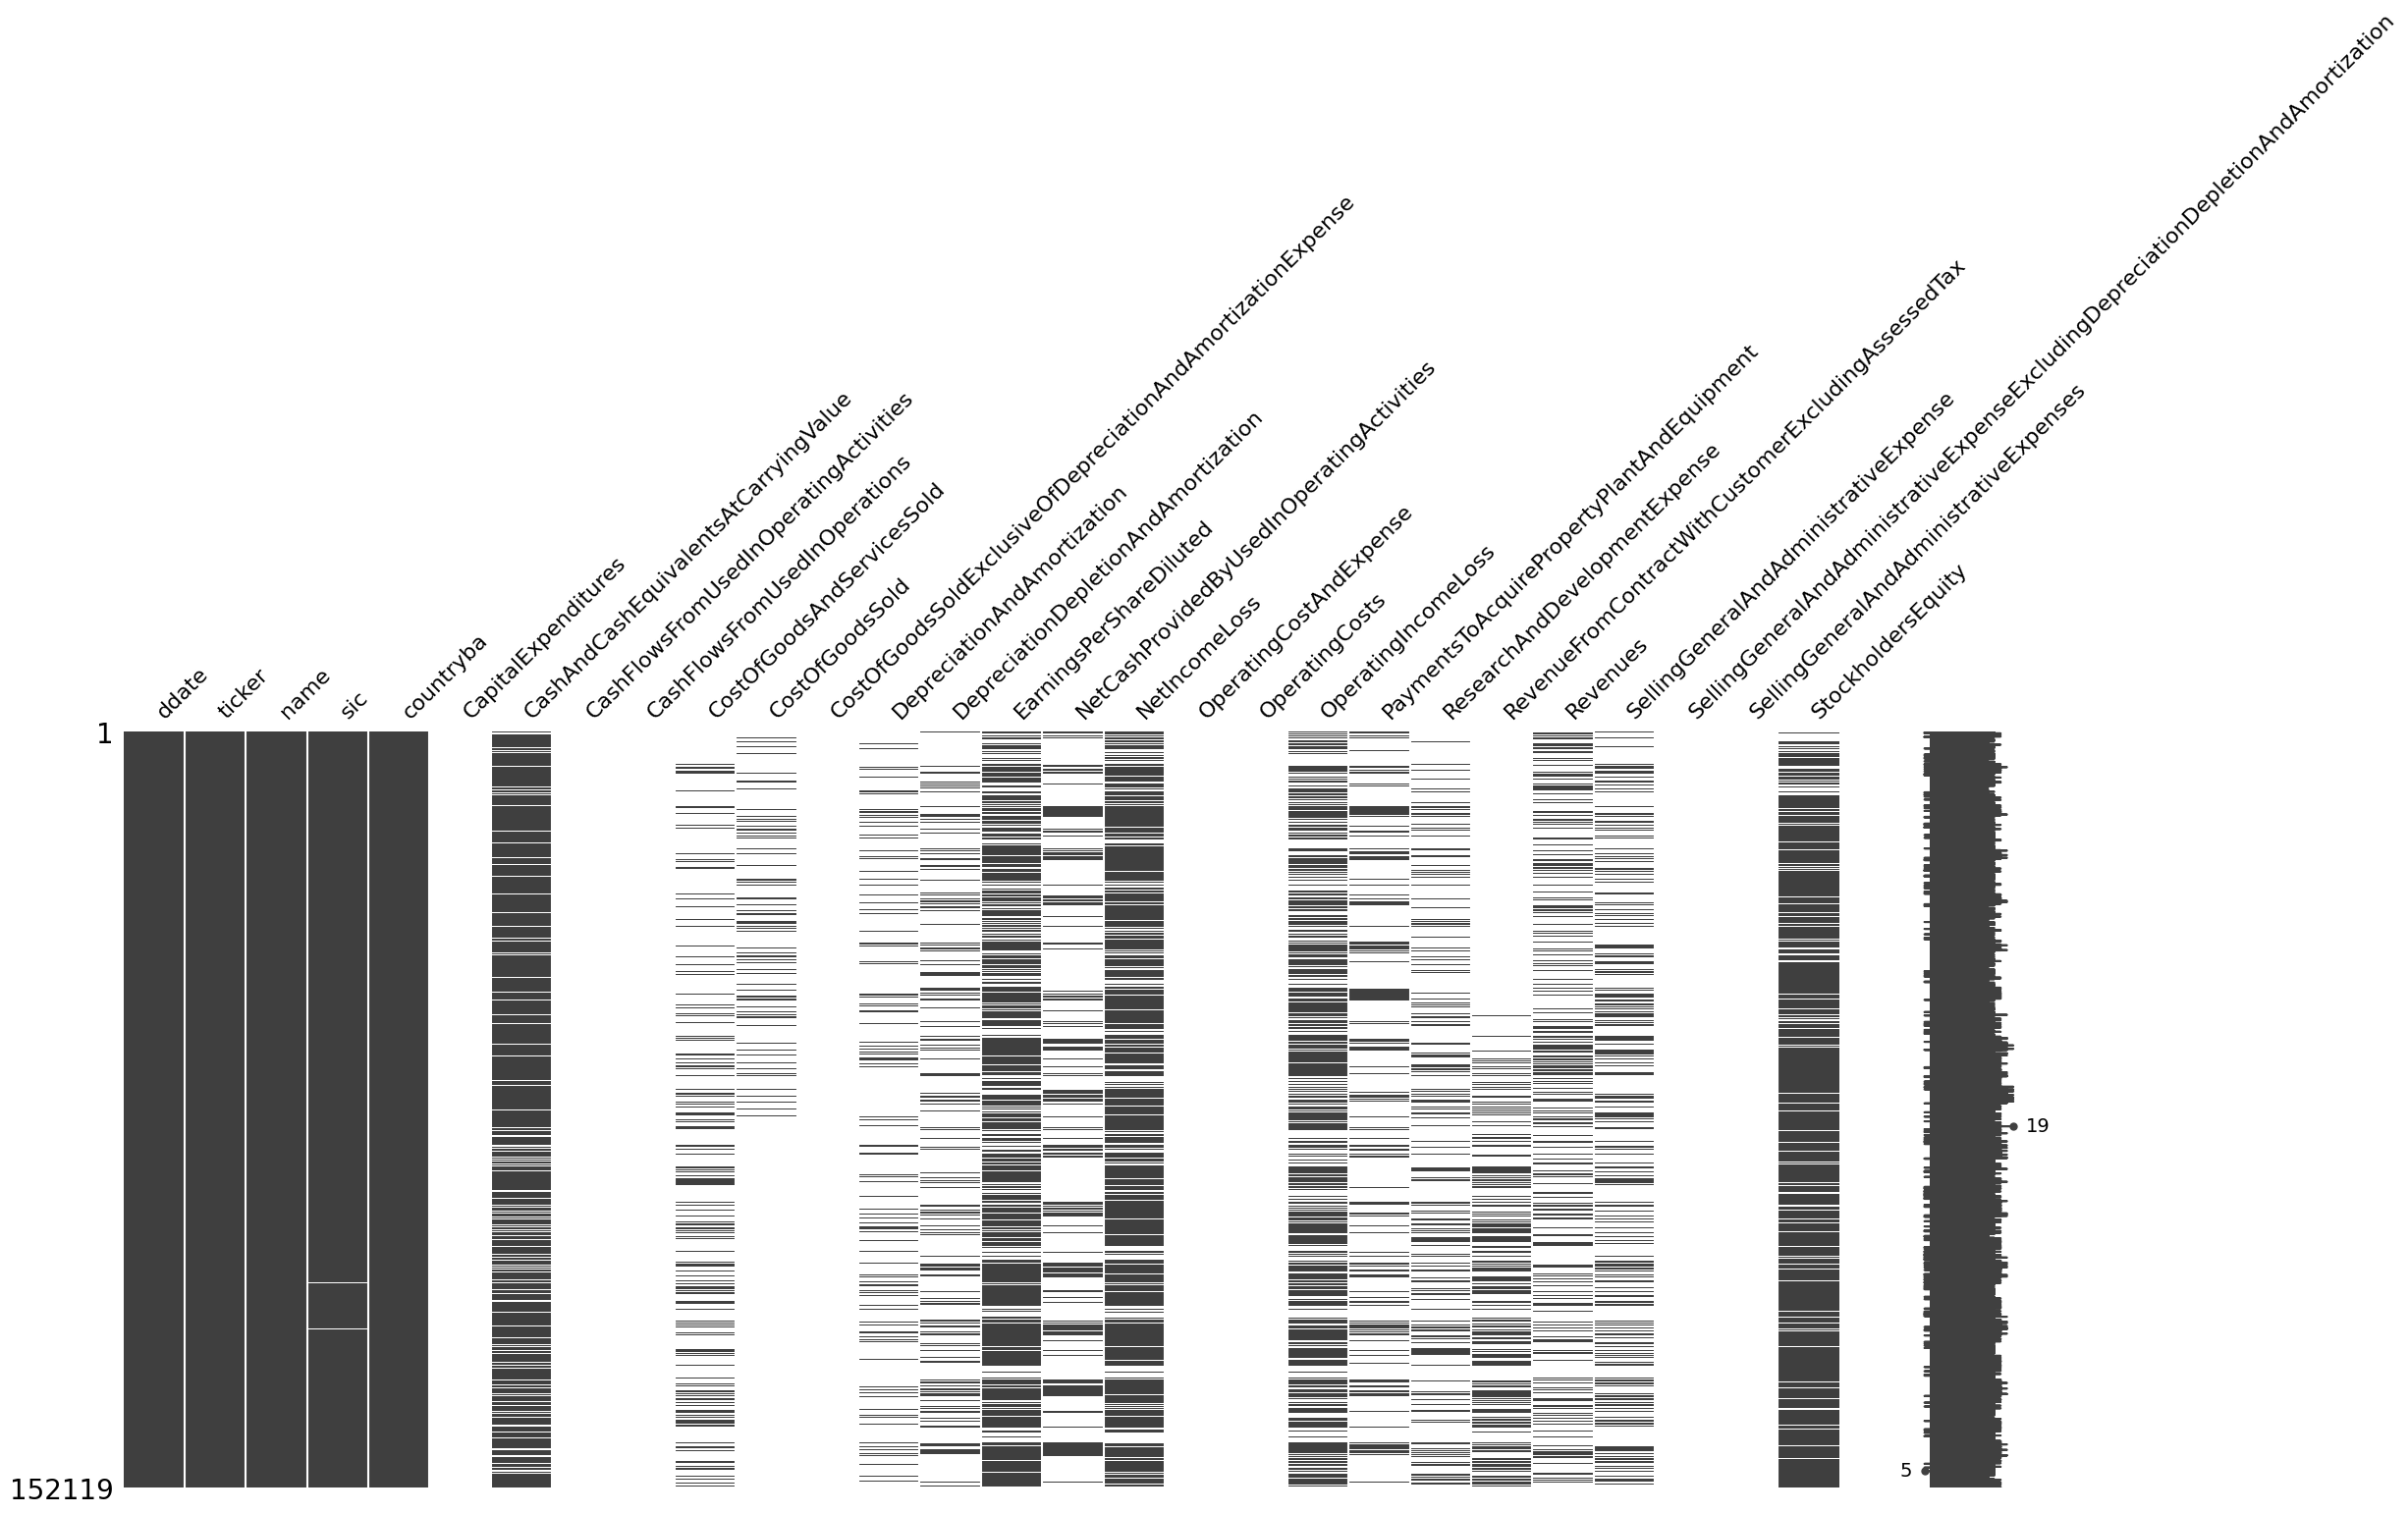

In [9]:
import numpy as np
import missingno as msno
import matplotlib.pyplot as plt

msno.matrix(master_filtered_6)
plt.show()

One thing to note is the ‘RevenueFrom…Tax’ column being empty until a certain date. This is because around 2018 US GAAP reporting standards changed resulting in the creation of this new feature. This column represents Top Line Revenue, one of the most important metrics for a business, so it is necessary to find a way around this absence of data. Fortunately, the Revenues feature represents the exact same data and thus both columns were merged for a more wholistic picture.

In [ ]:
# Spot check that Revenues is a matching proxy for RevenueFromContractWithCustomerExcludingAssessedTax in case of missing data
spotcheck_rev_matches_rev = master_filtered_6.dropna(subset=['RevenueFromContractWithCustomerExcludingAssessedTax', 'Revenues'])
print(spotcheck_rev_matches_rev[['RevenueFromContractWithCustomerExcludingAssessedTax', 'Revenues']].head(20))

tag    RevenueFromContractWithCustomerExcludingAssessedTax      Revenues
61918                                       3.347500e+07    3.347500e+07
64582                                       3.439600e+07    3.439600e+07
67208                                       3.395200e+07    3.395200e+07
68355                                       8.953000e+08    8.953000e+08
69490                                       1.789000e+08    1.775000e+08
69833                                       3.303700e+07    3.303700e+07
70143                                       6.762000e+08    5.841000e+08
70599                                       2.809900e+10    2.809900e+10
70637                                       1.990000e+05    1.990980e+05
71025                                       8.926000e+08    8.926000e+08
71475                                       1.041700e+07    1.041700e+07
72220                                       9.269000e+06    9.269000e+06
72305                                       1.96700

tag    RevenueFromContractWithCustomerExcludingAssessedTax      Revenues  \
61918                                       3.347500e+07    3.347500e+07   
64582                                       3.439600e+07    3.439600e+07   
67208                                       3.395200e+07    3.395200e+07   
68355                                       8.953000e+08    8.953000e+08   
69490                                       1.789000e+08    1.775000e+08   
69833                                       3.303700e+07    3.303700e+07   
70143                                       6.762000e+08    5.841000e+08   
70599                                       2.809900e+10    2.809900e+10   
70637                                       1.990000e+05    1.990980e+05   
71025                                       8.926000e+08    8.926000e+08   
71475                                       1.041700e+07    1.041700e+07   
72220                                       9.269000e+06    9.269000e+06   
72305       

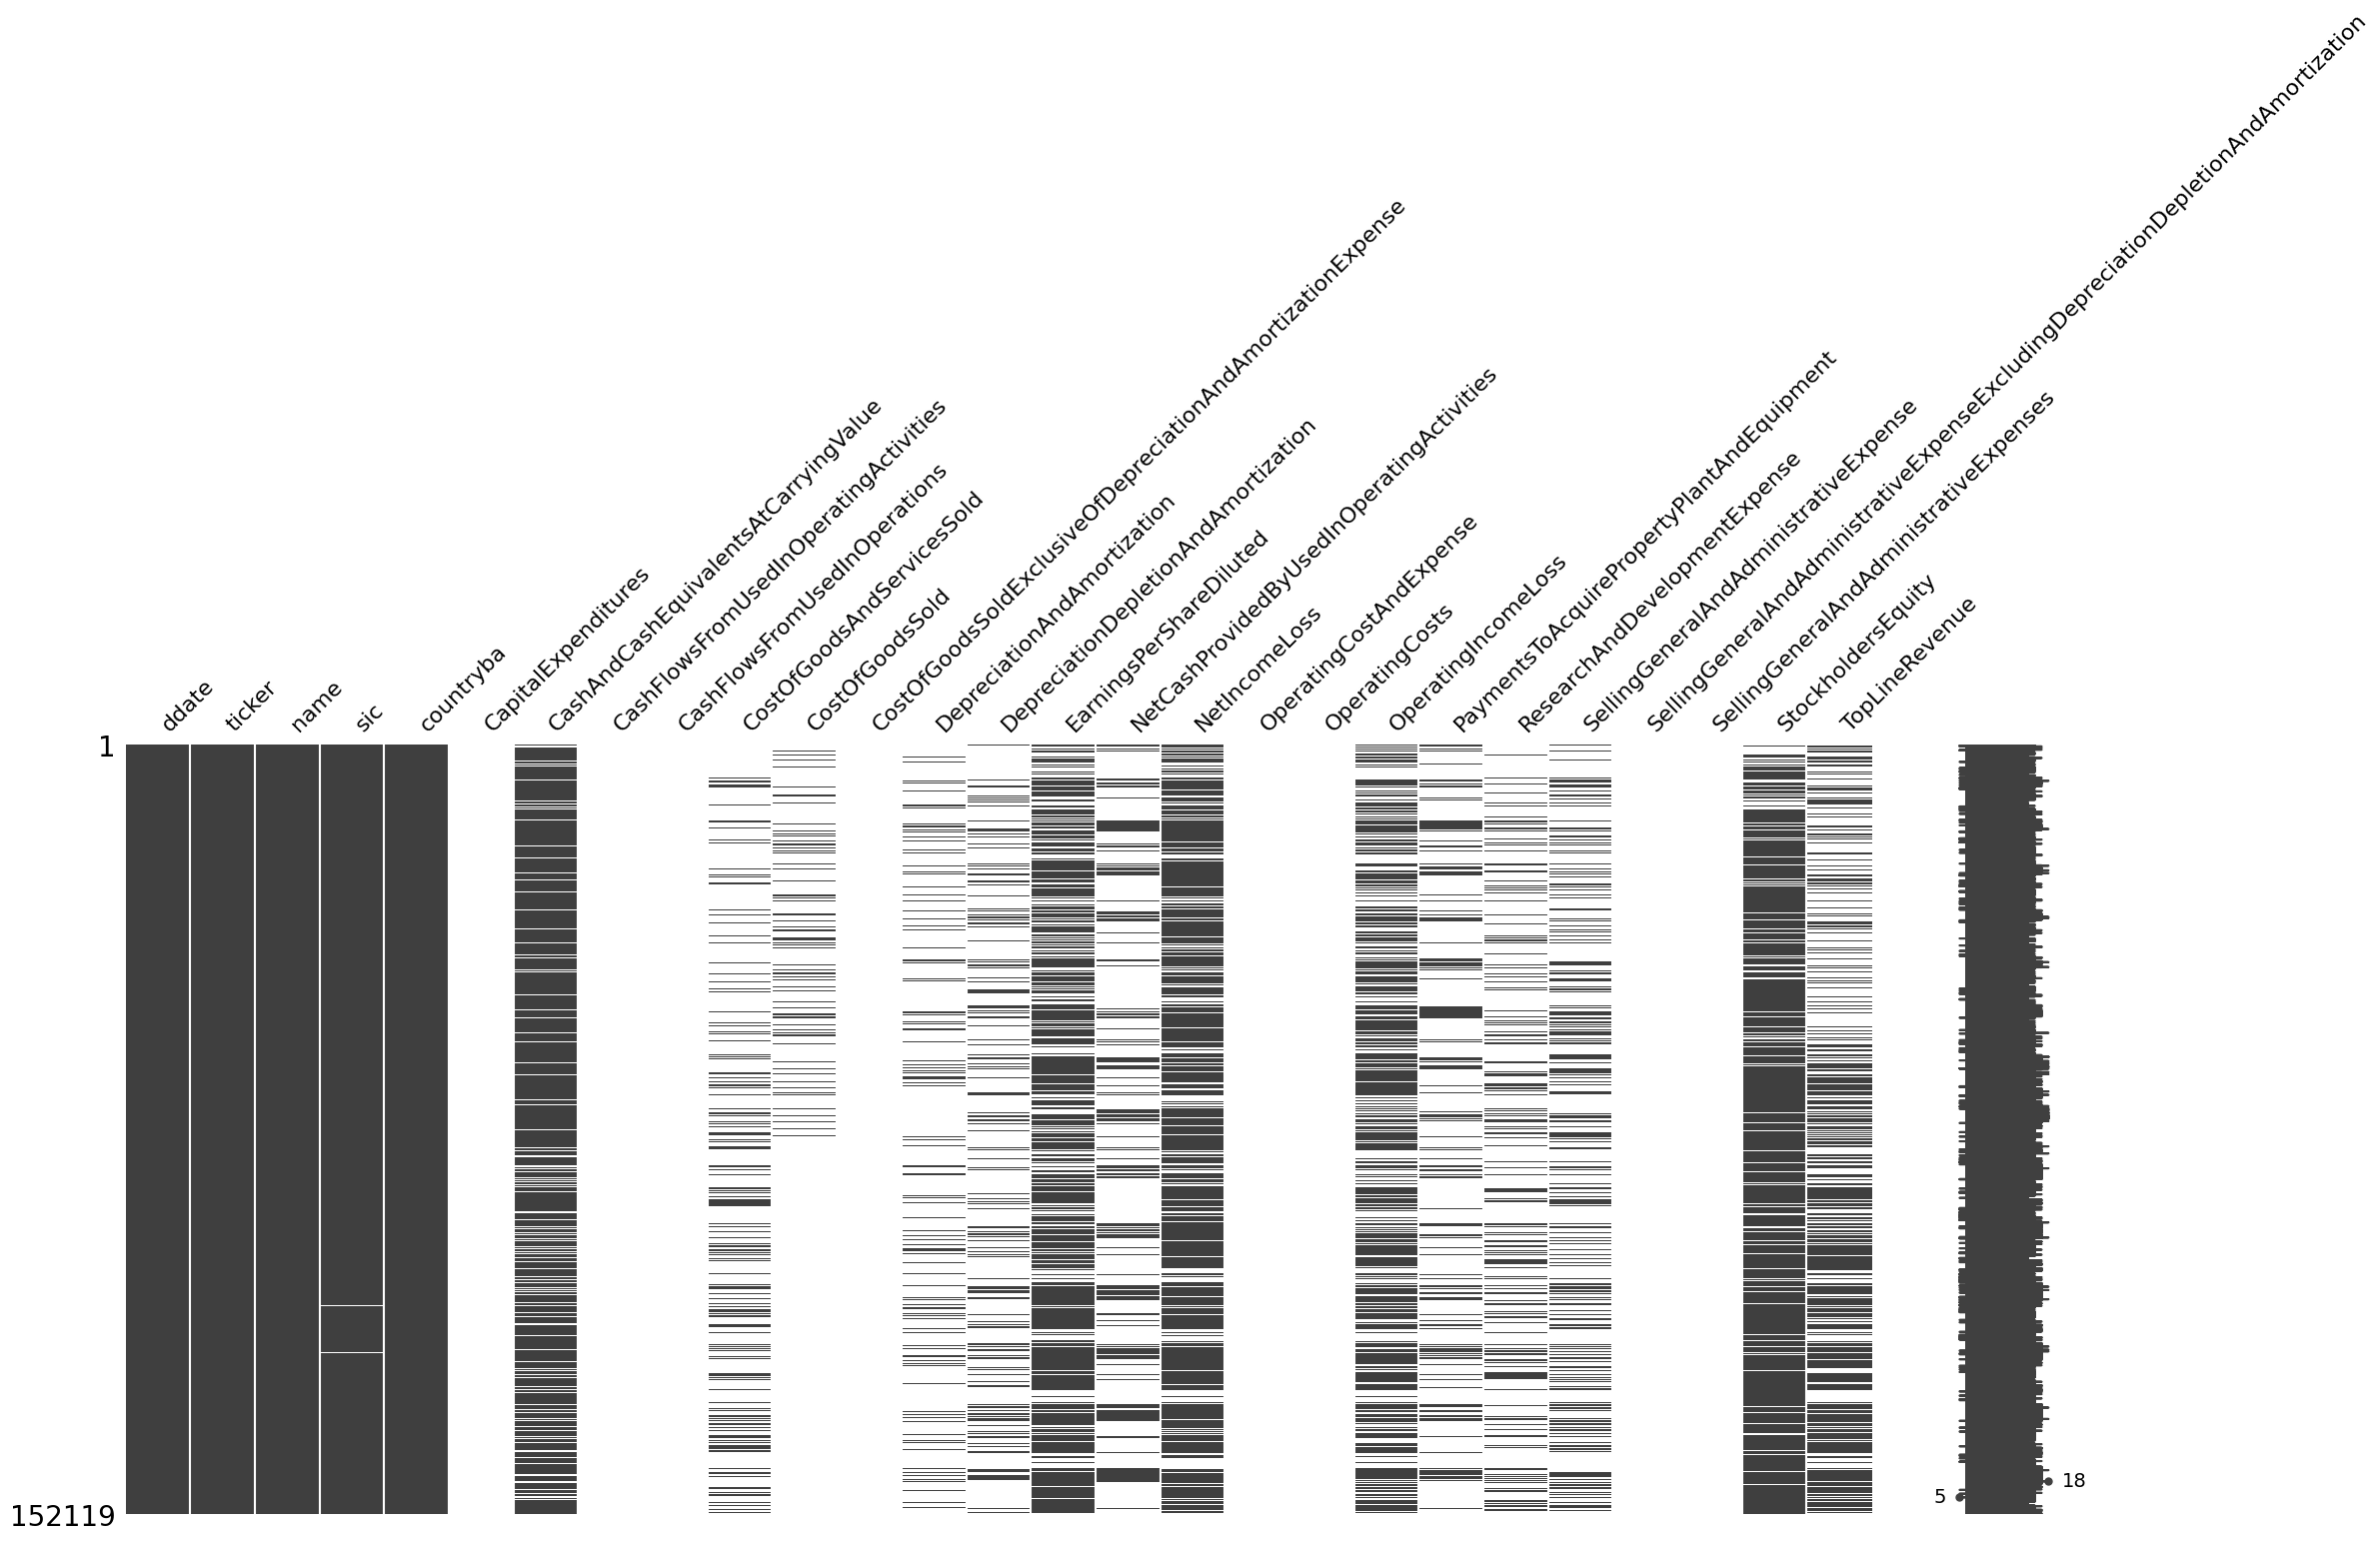

In [ ]:
# Combine the columns 'RevenueFromContractWithCustomerExcludingAssessedTax' and 'Revenues'
# Use the values from 'Revenues' where 'RevenueFromContractWithCustomerExcludingAssessedTax' is NaN
master_filtered_6['TopLineRevenue'] = master_filtered_6['RevenueFromContractWithCustomerExcludingAssessedTax'].fillna(master_filtered_6['Revenues'])

spotcheck_rev_matches_rev_2 = master_filtered_6.dropna(subset=['RevenueFromContractWithCustomerExcludingAssessedTax', 'Revenues', 'TopLineRevenue'])
print(spotcheck_rev_matches_rev_2[['RevenueFromContractWithCustomerExcludingAssessedTax', 'Revenues', 'TopLineRevenue']].head(20))

# Remove the columns 'RevenueFromContractWithCustomerExcludingAssessedTax' and 'Revenues'
master_filtered_7 = master_filtered_6.drop(columns=['RevenueFromContractWithCustomerExcludingAssessedTax', 'Revenues'])

# Run missingno again
msno.matrix(master_filtered_7)
plt.show()

Many of the tags that were perceived as important had almost completely empty columns and thus can be dropped.

In [ ]:
# Drop blank columns. Drop countryba because all values are US
master_filtered_8 = master_filtered_7.drop(columns=['countryba','CostOfGoodsSold','OperatingCostAndExpense',
                                           'SellingGeneralAndAdministrativeExpenseExcludingDepreciationDepletionAndAmortization',
                                           'SellingGeneralAndAdministrativeExpenses','CashFlowsFromUsedInOperatingActivities',
                                           'CashFlowsFromUsedInOperations'])

Check that we can also perform the same combination of columns for D&A as we did for Top Line Revenue

In [ ]:
# Spot check that D&A is a matching proxy for DD&A in case of missing data
spotcheck_rev_matches_rev = master_filtered_6.dropna(subset=['DepreciationAndAmortization', 'DepreciationDepletionAndAmortization'])
print(spotcheck_rev_matches_rev[['DepreciationAndAmortization', 'DepreciationDepletionAndAmortization']].head(20))

tag   DepreciationAndAmortization  DepreciationDepletionAndAmortization
7414                  488000000.0                           488000000.0
7488                    7066000.0                             7066000.0
7512                  638498000.0                           638498000.0
7548                   52102000.0                            52566000.0
7562                  -73061000.0                            75657000.0
7580                   83075000.0                            83075000.0
7592                   72883000.0                            70449000.0
7602                   16753000.0                            16753000.0
7643                   42968000.0                            43507000.0
7655                   25806000.0                            27381000.0
7667                   24964000.0                            25198000.0
7668                  146706000.0                           147679000.0
7671                  269000000.0                           3200

In [ ]:
# Combine D&A columns
master_filtered_8['D_A'] = master_filtered_8['DepreciationAndAmortization'].fillna(master_filtered_8['DepreciationDepletionAndAmortization'])

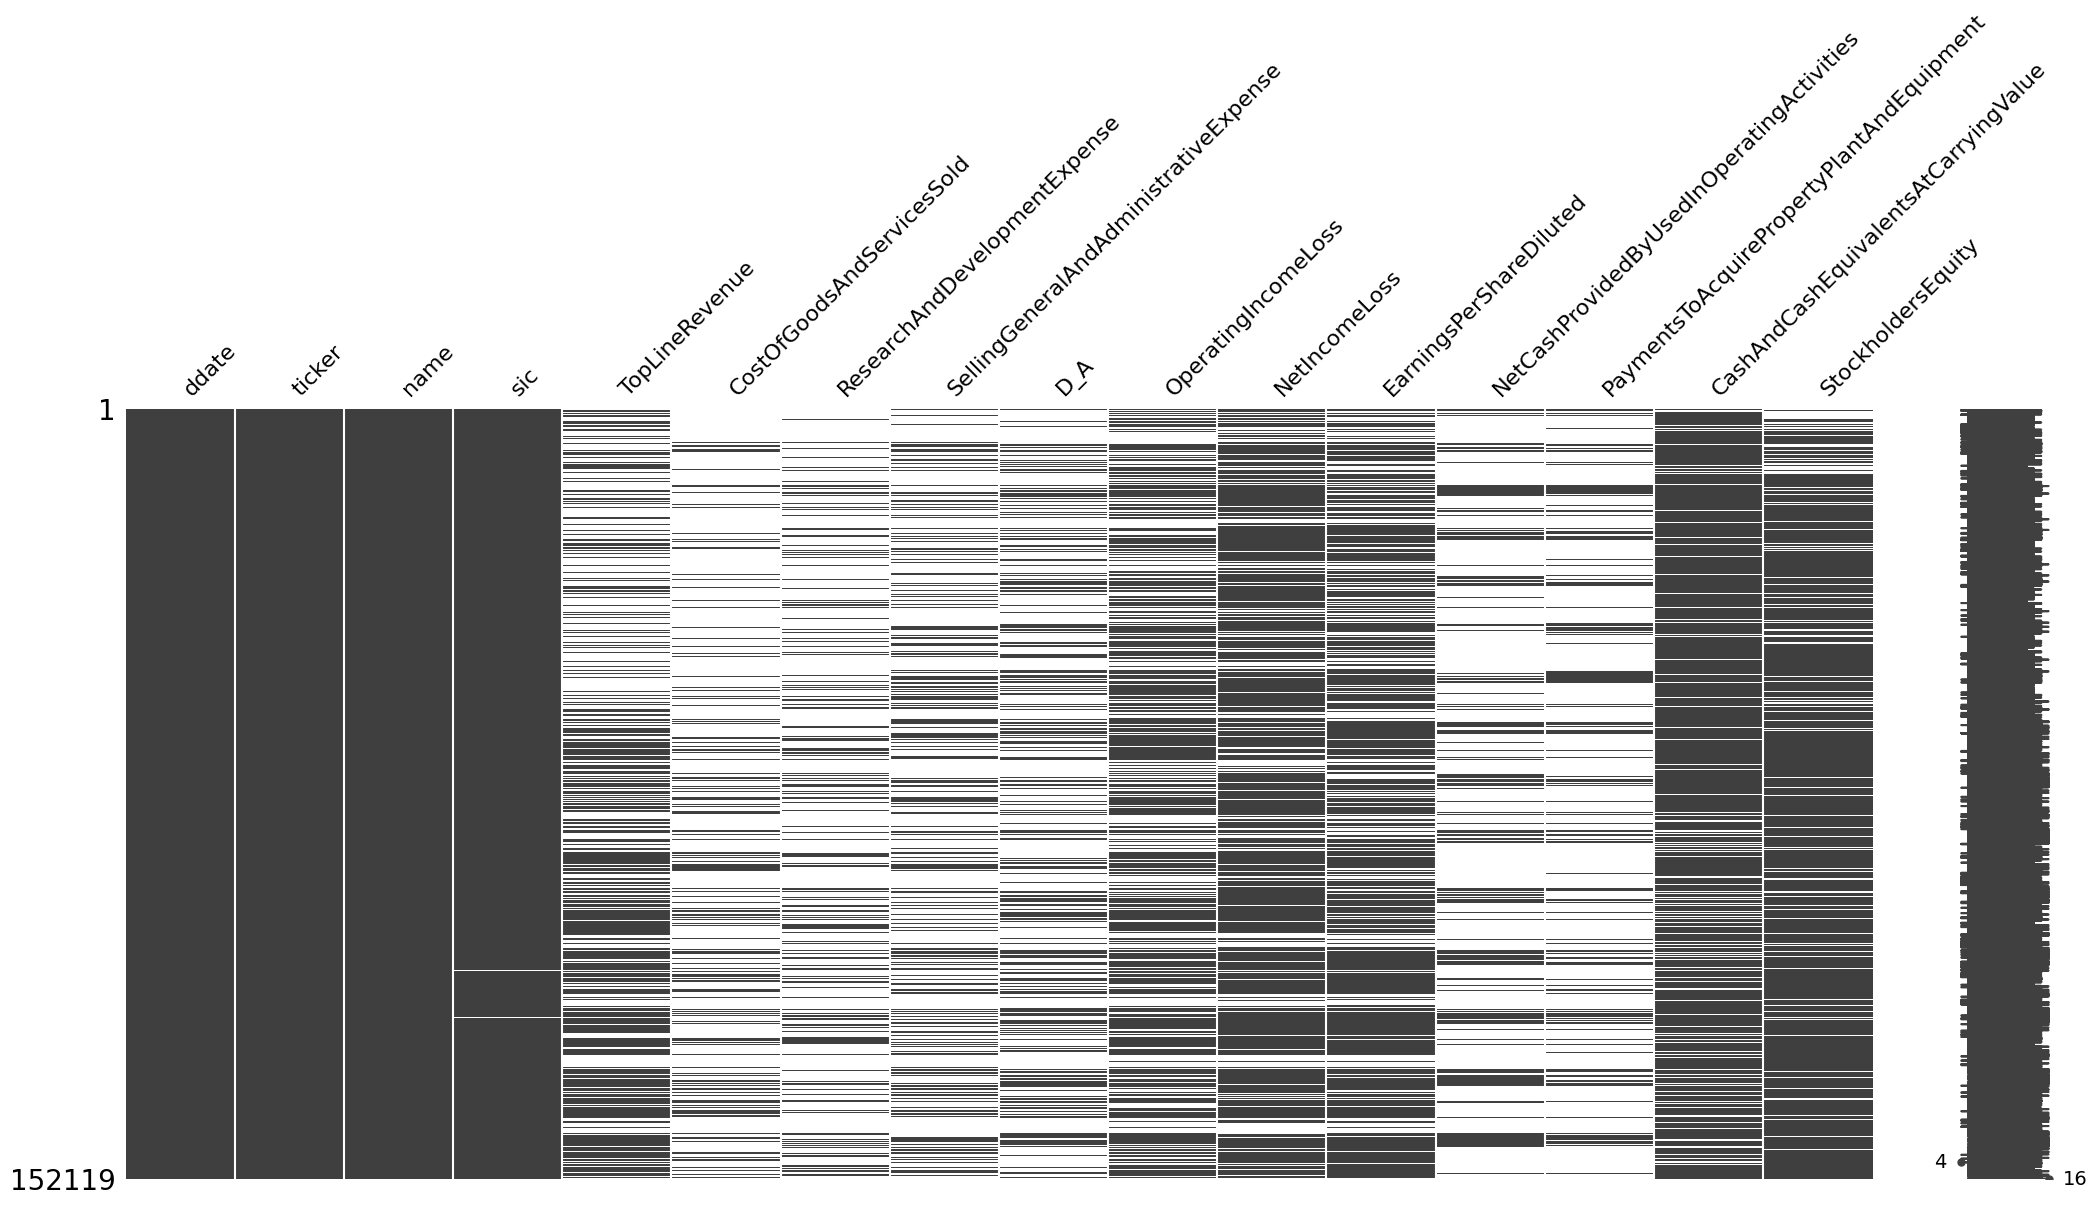

In [ ]:
# Put the columns in the correct order like an income statement
column_order = ['ddate', 'ticker', 'name', 'sic', 
                'TopLineRevenue',  
                'CostOfGoodsAndServicesSold',  
                'ResearchAndDevelopmentExpense',  
                'SellingGeneralAndAdministrativeExpense',  
                'D_A',  
                'OperatingIncomeLoss',  
                'NetIncomeLoss',  
                'EarningsPerShareDiluted',  
                'NetCashProvidedByUsedInOperatingActivities',  
                'PaymentsToAcquirePropertyPlantAndEquipment',  
                'CashAndCashEquivalentsAtCarryingValue',  
                'StockholdersEquity']

master_filtered_8 = master_filtered_8[column_order]

# Create the missingno matrix for master_filtered_8
msno.matrix(master_filtered_8)
plt.show()

To fill in as much missing data as possible in TopLineRevenue and OperatingIncome columns, COGS, R&D, SG&A, and D&A columns were used and summed where data was available in all four. Then any of the remaining columns with >50% missingness were dropped. Some columns had >80% missing data which unfortunately simply couldn’t be handled in any meaningful way. 

For the remaining columns, linear interpolation is used to impute each ticker’s gaps in reporting. It is possible to use this method because a company’s high level summary data doesn’t vary drastically from quarter to quarter. 

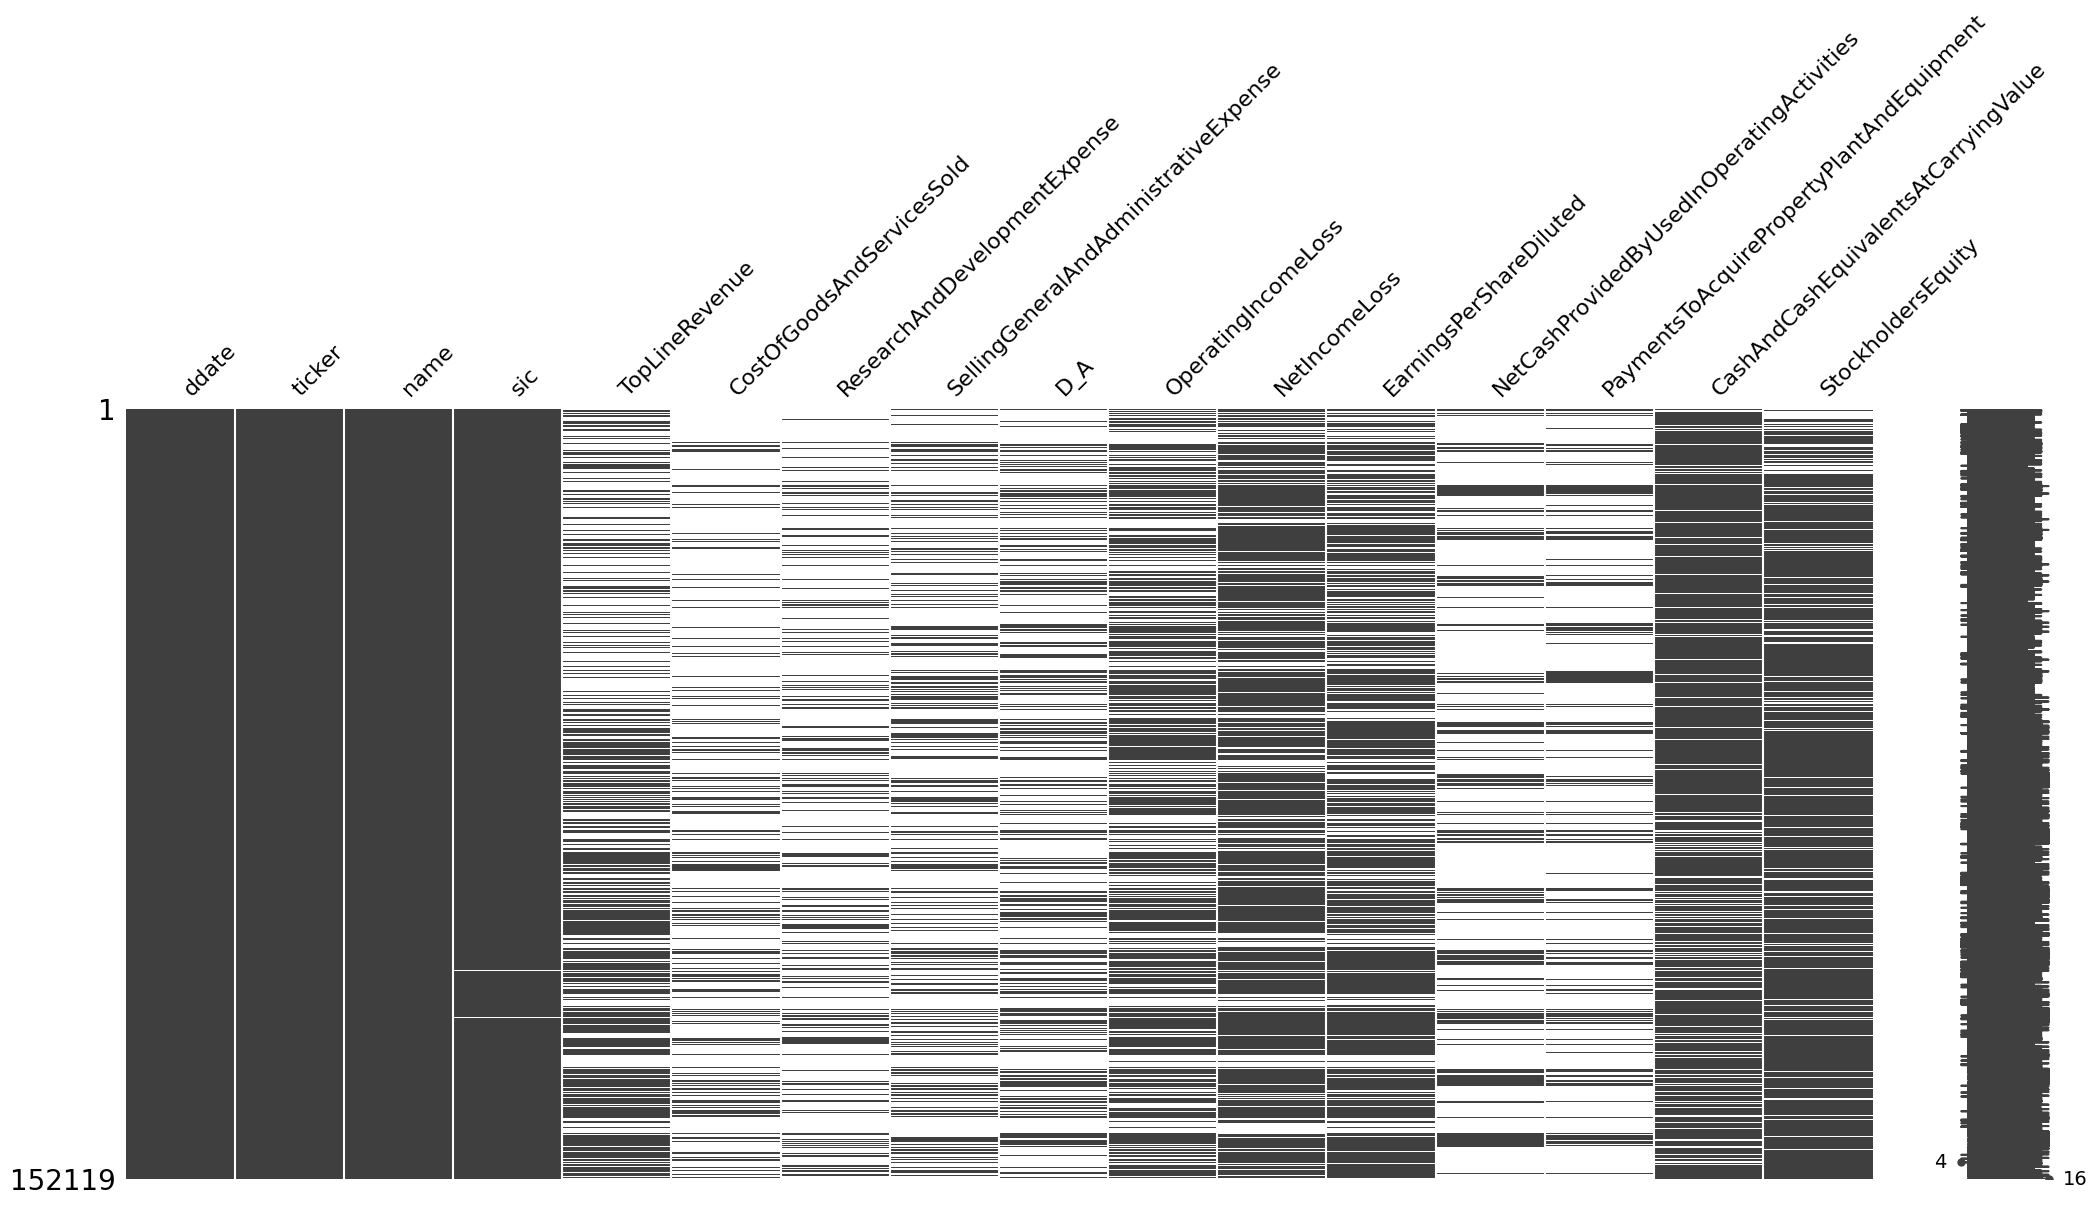

In [ ]:
# First calculate OperatingIncomeLoss as TopLineRevenue - CostOfGoodsAndServicesSold - ResearchAndDevelopmentExpense - SellingGeneralAndAdministrativeExpense - DepreciationDepletionAndAmortization
# Where there are no missing values in any of the columns
master_filtered_9 = master_filtered_8.copy()

# Filter rows where there are no missing values in the specified columns
operatingincomeloss_calc = master_filtered_9.dropna(subset=[
    'TopLineRevenue', 
    'CostOfGoodsAndServicesSold', 
    'ResearchAndDevelopmentExpense', 
    'SellingGeneralAndAdministrativeExpense', 
    'D_A'
])

# Calculate OperatingIncomeLoss
master_filtered_9['OperatingIncomeLoss'] = master_filtered_9['OperatingIncomeLoss'].fillna(
    operatingincomeloss_calc['TopLineRevenue'] - 
    operatingincomeloss_calc['CostOfGoodsAndServicesSold'] - 
    operatingincomeloss_calc['ResearchAndDevelopmentExpense'] - 
    operatingincomeloss_calc['SellingGeneralAndAdministrativeExpense'] - 
    operatingincomeloss_calc['D_A']
)

# Show updated missingno matrix
msno.matrix(master_filtered_9)
plt.show()

In [ ]:
# Create a copy of the DataFrame
master_filtered_10 = master_filtered_9.copy()

# Impute missing values in the 'sic' column with the value that matches the same 'ticker'
master_filtered_10['sic'] = master_filtered_10.groupby('ticker')['sic'].transform(lambda x: x.fillna(method='ffill').fillna(method='bfill'))

# Impute the columns that have low amounts of missing data using linear interpolation grouped on ticker
master_imputed = master_filtered_10.copy()
master_imputed['TopLineRevenue'] = master_filtered_10.groupby('ticker')['TopLineRevenue'].transform(lambda x: x.interpolate())
master_imputed['OperatingIncomeLoss'] = master_filtered_10.groupby('ticker')['OperatingIncomeLoss'].transform(lambda x: x.interpolate())
master_imputed['NetIncomeLoss'] = master_filtered_10.groupby('ticker')['NetIncomeLoss'].transform(lambda x: x.interpolate())
master_imputed['EarningsPerShareDiluted'] = master_filtered_10.groupby('ticker')['EarningsPerShareDiluted'].transform(lambda x: x.interpolate())
master_imputed['CashAndCashEquivalentsAtCarryingValue'] = master_filtered_10.groupby('ticker')['CashAndCashEquivalentsAtCarryingValue'].transform(lambda x: x.interpolate())
master_imputed['StockholdersEquity'] = master_filtered_10.groupby('ticker')['StockholdersEquity'].transform(lambda x: x.interpolate())

# Get the percentage of missing values in each column
pct_missing = master_imputed.isnull().mean() * 100
pct_missing

C:\Users\tjbos\AppData\Local\Temp\ipykernel_22300\2254819946.py:5: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  master_filtered_10['sic'] = master_filtered_10.groupby('ticker')['sic'].transform(lambda x: x.fillna(method='ffill').fillna(method='bfill'))


tag
ddate                                          0.000000
ticker                                         0.000000
name                                           0.000000
sic                                            0.352356
TopLineRevenue                                36.917808
CostOfGoodsAndServicesSold                    80.068893
ResearchAndDevelopmentExpense                 77.523518
SellingGeneralAndAdministrativeExpense        70.129964
D_A                                           69.208317
OperatingIncomeLoss                           23.869471
NetIncomeLoss                                  5.933513
EarningsPerShareDiluted                       14.582662
NetCashProvidedByUsedInOperatingActivities    78.479348
PaymentsToAcquirePropertyPlantAndEquipment    81.223253
CashAndCashEquivalentsAtCarryingValue          5.521335
StockholdersEquity                             5.564722
dtype: float64

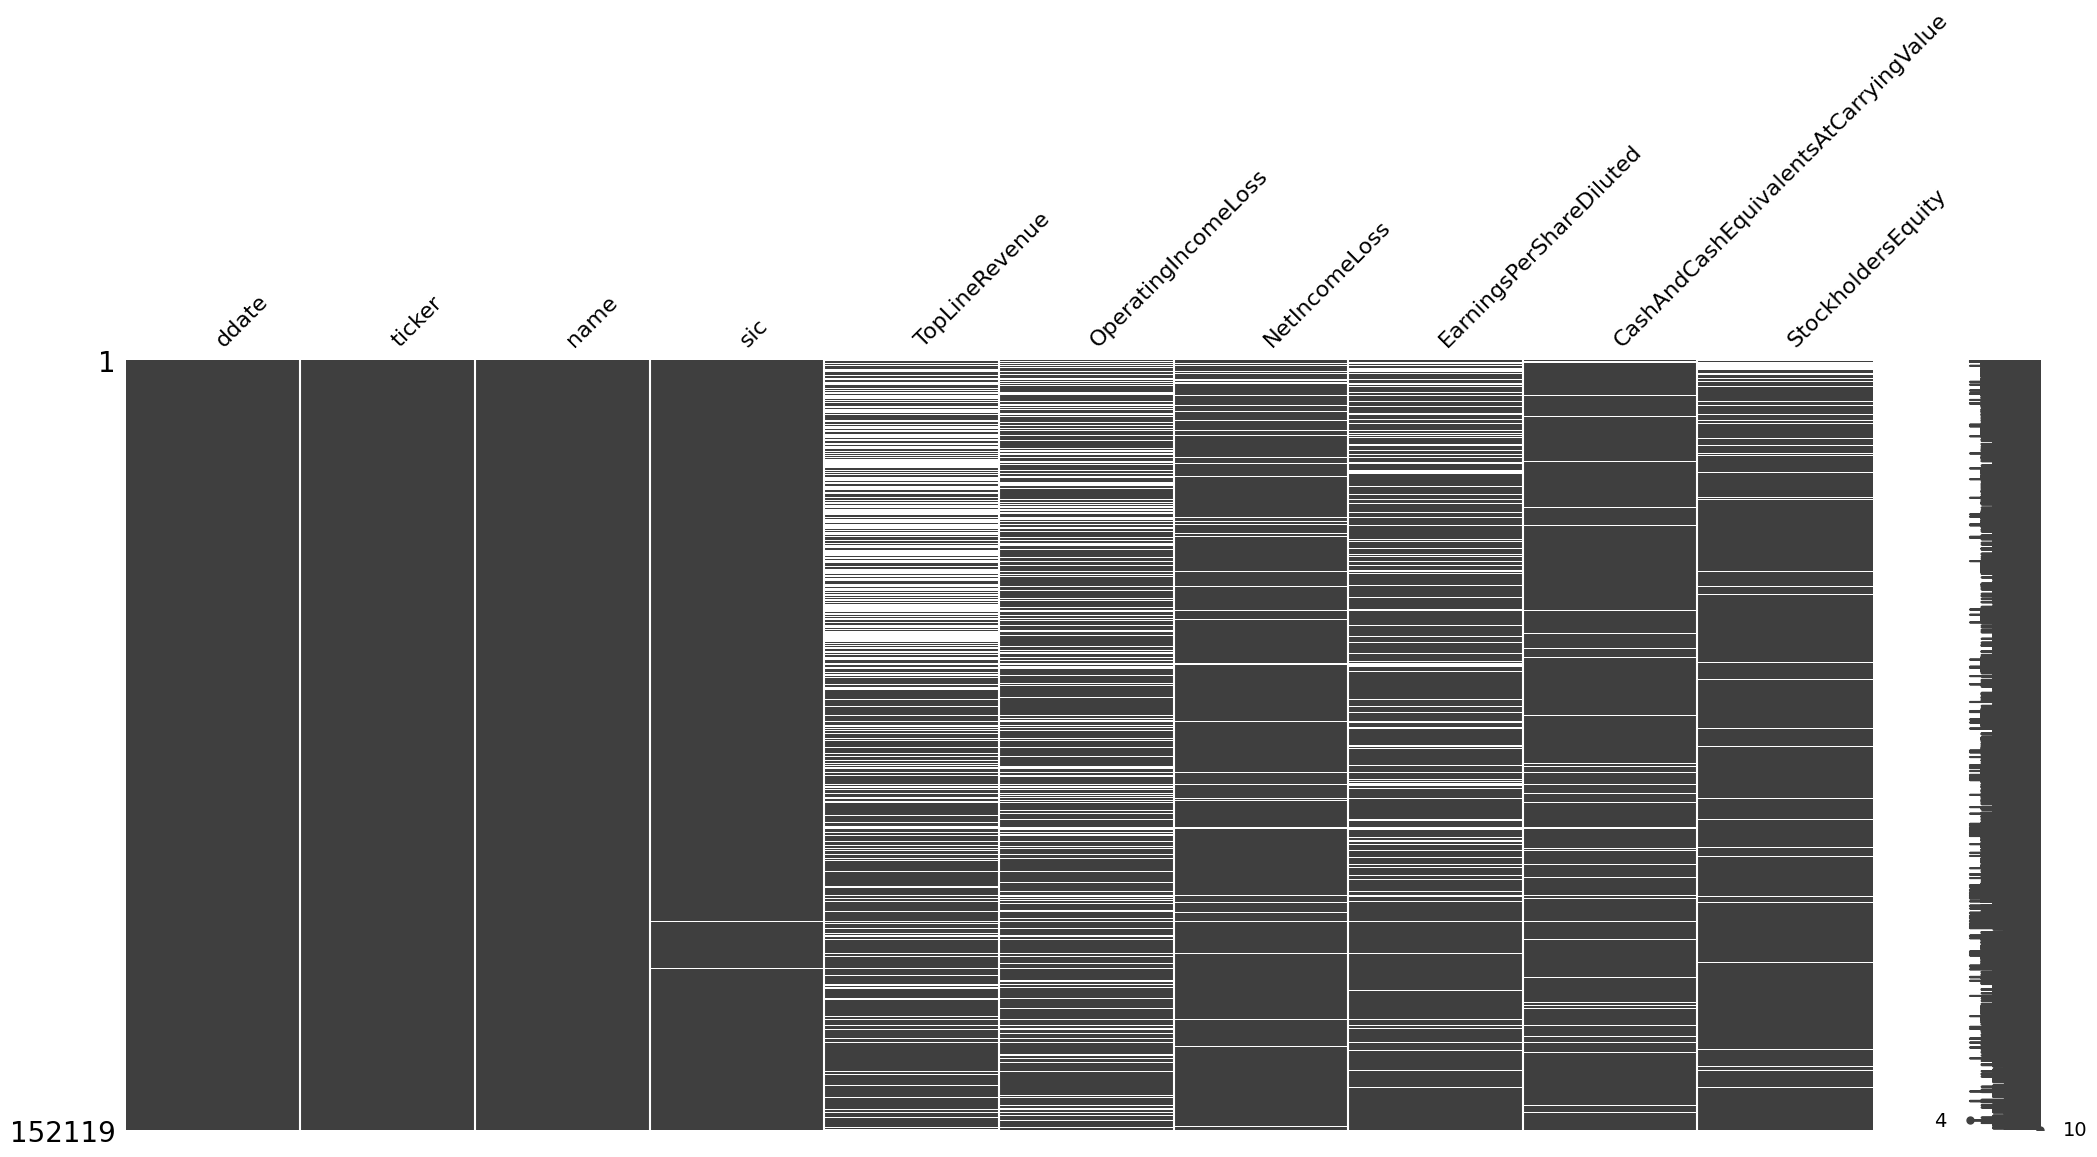

In [ ]:
# Drop high missing value columns
master_imputed_dropped = master_imputed.copy()
master_imputed_dropped.drop(columns=['CostOfGoodsAndServicesSold',
                                    'ResearchAndDevelopmentExpense',
                                    'SellingGeneralAndAdministrativeExpense',
                                    'D_A',
                                    'PaymentsToAcquirePropertyPlantAndEquipment', 
                                    'NetCashProvidedByUsedInOperatingActivities'], inplace=True)

# Show the new missingno matrix for master_imputed_dropped
msno.matrix(master_imputed_dropped)
plt.show()

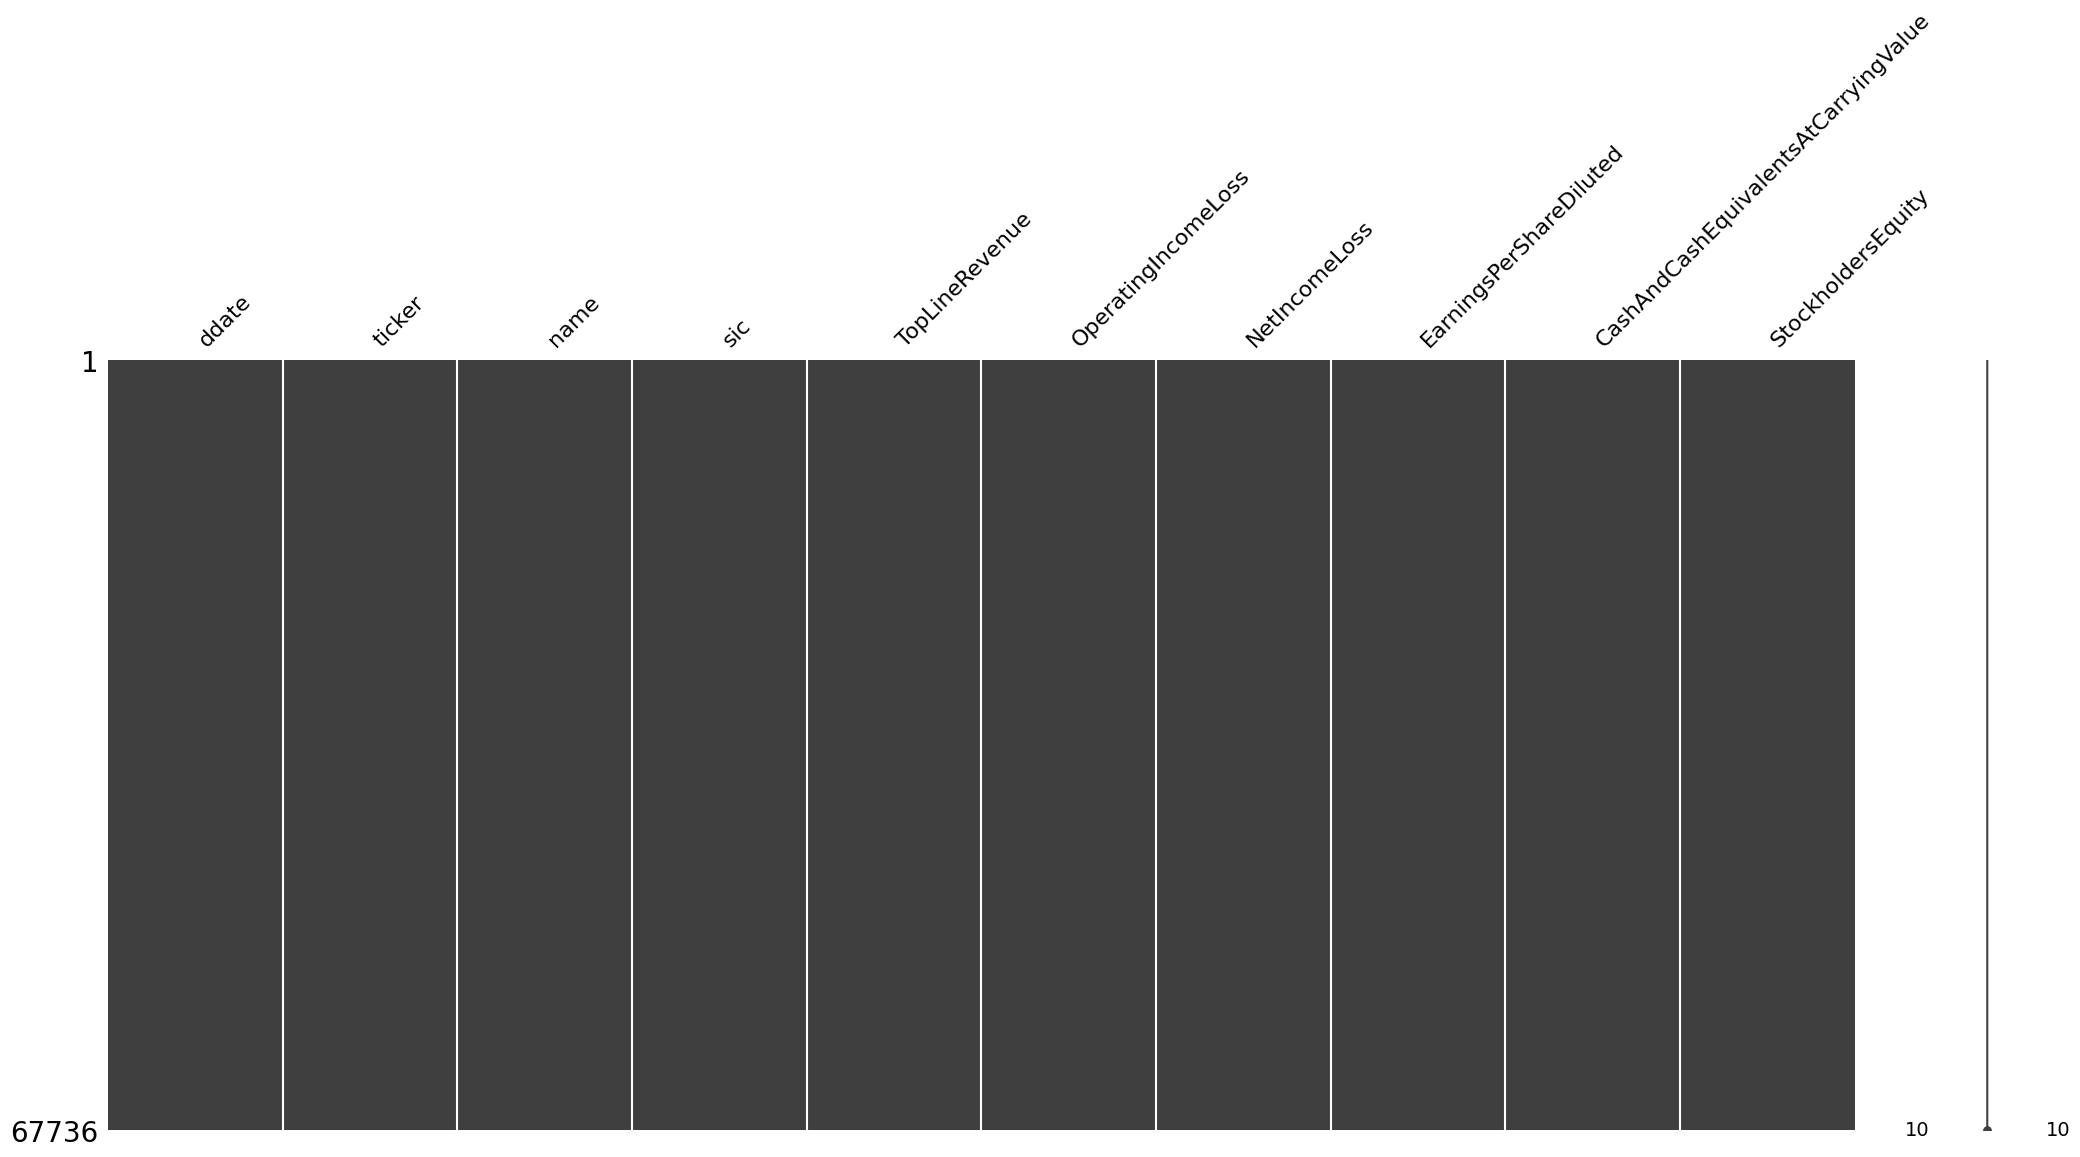

In [ ]:
# Test dropping any row with na
test_drop = master_imputed_dropped.copy()
test_drop.dropna(inplace=True)
msno.matrix(test_drop)
plt.show()

In [ ]:
# Get the number of unique tickers
test_drop['ticker'].nunique()

# 2421 is still a good sample size, and 2421 / 67736 means there is still a bit of data for each stock

2421

At this point it is possible to remove all rows with missing values without culling the entire data set.

 As an additional precaution individual stocks with fewer than 20 observations in the data set were also removed. The resulting data now contains 1011 unique stock tickers, 43563 rows, spanning all 179 months between Jan 2010 and Dec 2024.

In [ ]:
# Find the stocks that have the least data points in the set
ticker_counts = test_drop['ticker'].value_counts()

# Remove lines where ticker < 20
master_imputed_dropped_filtered = test_drop[test_drop['ticker'].isin(ticker_counts[ticker_counts > 30].index)]
print("Unique Tickers:", master_imputed_dropped_filtered['ticker'].nunique())
print(len(master_imputed_dropped_filtered))
print(master_imputed_dropped_filtered['ddate'].nunique())

Unique Tickers: 1011
43563
179


### Joining Yahoo Finance Data

You may have noticed we still did not add the Yahoo finance data to the set. Now it is time to complete this merger. First, all monthly historical pricing data was read in from Yahoo Finance for each ticker and stored in their own files locally to avoid data loss if the program was booted by Yahoo’s API. Then all local files were read into a single data frame where they could then be merged with the SEC data on date and ticker. After the merge there were about ~4% of rows missing from the Yahoo Finance data set and these could simply be dropped. 

In [ ]:
import yfinance as yf

# Define a function to scrape yahoo finance for the monthly historical pricing data between 1/1/2010 and 12/31/2024
def get_historical_prices(ticker):
    try:
        # Get the historical data for the specified ticker
        historical_data = yf.Ticker(ticker).history(start='2010-01-01', end='2025-01-02', interval = '1mo')
        
        # Reset the index of the DataFrame
        historical_data.reset_index(inplace=True)
        
        # Return the historical data
        return historical_data
    except:
        # If an error occurs, return None
        return f"Error fetching data for ticker {ticker}"

! WARNING !

The following code is used to scrape Yahoo Finance HTML. This code takes several minutes to run and is prone to being blocked mid-run by Yahoo. Due to this, the final data frame resulting from the next few cells of code will not be viewable via the code. For future parts, a premade file with the scraped data is read in. The code below serves only for demonstration purposes.

In [ ]:
### RUN ONE TIME THEN COMMENT OUT ###
# Create a loop that iterates through the unique tickers and fetches the historical data
historical_data = pd.DataFrame()

i = 0

master_imputed_dropped_filtered['ticker'].unique()

for ticker in master_imputed_dropped_filtered['ticker'].unique():
   i+=1

   data = get_historical_prices(ticker)
   data.to_parquet(f'../data/raw/price_batches/{ticker}.parquet')

   print(f'Iteration #{i}: Fetched data for {ticker}')


# Read all individual pricing parquet files into a single DataFrame
master_price_data = pd.DataFrame()

for ticker in master_imputed_dropped_filtered['ticker'].unique():
   data = pd.read_parquet(f'../data/raw/price_batches/{ticker}.parquet')
   data['ticker'] = ticker
   master_price_data = pd.concat([master_price_data, data], ignore_index=True)


# Shift the month column back by one month to align with the fundamental data
# Right now this is the first of the month, the other is the last day of the month. When they are both in yyyymm format, they will align

master_price_data['Date'] = pd.to_datetime(master_price_data['Date'], format='%Y%m') - pd.offsets.MonthBegin(1)
master_price_data['Date'] = master_price_data['Date'].dt.strftime('%Y%m')

master_price_data.to_csv('../data/clean/master_price_data.csv', index=False)

In [ ]:
# For the sake of the demo, we will read the CSV file instead of running the above code to fetch data from Yahoo Finance
master_price_data = pd.read_csv('../data/clean/master_price_data.csv')

Now it is time to perform the final data maniplation before the creation of the final master file. We will join the data sets on date and ticker, remove the few rows that are empty, drop unneccessary columns, and create the target variable of strong sell to strong buy represented by integers from -2 to 2.

In [ ]:
# Join the Yahoo Finance data with the fundamental data
# Match the date format
master_fundamental_prejoin = master_imputed_dropped_filtered.copy()
master_fundamental_prejoin['ddate'] = pd.to_datetime(master_fundamental_prejoin['ddate'], format='%Y%m%d')
master_fundamental_prejoin['ddate'] = master_fundamental_prejoin['ddate'].dt.strftime('%Y%m')

# Ensure 'Date' in master_price_data is also a string
master_price_data['Date'] = master_price_data['Date'].astype(str)

# Join the two DataFrames on 'ticker' and 'ddate'
master_joined = master_fundamental_prejoin.merge(master_price_data, left_on=['ticker', 'ddate'], right_on=['ticker', 'Date'], how='left')

# Remove rows with missing values
master_joined_dropped = master_joined.copy()
master_joined_dropped.dropna(inplace=True)

# Drop unnecessary columns
master_joined_dropped = master_joined_dropped.drop(columns=['Date', 'Open','High','Low'])

# Drop empty rows
master_joined_dropped.dropna(inplace=True)

# Rename Close to CurrentPrice and ddate to CurrentPeriodDate
master_joined_dropped.rename(columns={'Close': 'CurrentPrice', 'ddate': 'CurrentPeriodDate'}, inplace=True)

# Verify that the columns have been renamed correctly
print(master_joined_dropped.columns)

# Create a column called FuturePeriodPrice that is the price of the next month grouped by ticker
master_joined_dropped['FuturePeriodPrice'] = master_joined_dropped.groupby('ticker')['CurrentPrice'].shift(-1)
master_joined_dropped['FuturePeriodDate'] = master_joined_dropped.groupby('ticker')['CurrentPeriodDate'].shift(-1)

# Fill NaN values with a placeholder (e.g., 0)
master_joined_dropped['CurrentPeriodDate'].fillna(0, inplace=True)
master_joined_dropped['FuturePeriodDate'].fillna(0, inplace=True)

# Convert CurrentPeriodDate and FuturePeriodDate to integers
master_joined_dropped['CurrentPeriodDate'] = master_joined_dropped['CurrentPeriodDate'].astype(int)
master_joined_dropped['FuturePeriodDate'] = master_joined_dropped['FuturePeriodDate'].astype(int)

# Calculate the period length in months
master_joined_dropped['PeriodLength'] = (
    (master_joined_dropped['FuturePeriodDate'] // 100 - master_joined_dropped['CurrentPeriodDate'] // 100) * 12 +
    (master_joined_dropped['FuturePeriodDate'] % 100 - master_joined_dropped['CurrentPeriodDate'] % 100)
)

# Handle the placeholder values appropriately (e.g., set PeriodLength to NaN where FuturePeriodDate was originally NaN)
master_joined_dropped.loc[master_joined_dropped['FuturePeriodDate'] == 0, 'PeriodLength'] = np.nan

# Create a column called PeriodPctReturn that is the percentage change between CurrentPrice and FuturePeriodPrice
master_joined_dropped['PeriodPctReturn'] = (
    (master_joined_dropped['FuturePeriodPrice'] - master_joined_dropped['CurrentPrice']) / 
    master_joined_dropped['CurrentPrice']
)

# Drop the last few rows with missing values
master_joined_dropped.dropna(inplace=True)

# Create a column that calculates the average monthly compound return
master_joined_dropped['AvgMonthlyCompoundReturn'] = (
    (1 + master_joined_dropped['PeriodPctReturn']) ** (1 / master_joined_dropped['PeriodLength']) - 1
)

master_joined_dropped['AvgMonthlyCompoundReturn'].describe()

Index(['CurrentPeriodDate', 'ticker', 'name', 'sic', 'TopLineRevenue',
       'OperatingIncomeLoss', 'NetIncomeLoss', 'EarningsPerShareDiluted',
       'CashAndCashEquivalentsAtCarryingValue', 'StockholdersEquity',
       'CurrentPrice', 'Volume', 'Dividends', 'Stock Splits'],
      dtype='object')


C:\Users\tjbos\AppData\Local\Temp\ipykernel_22300\1550350287.py:34: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  master_joined_dropped['CurrentPeriodDate'].fillna(0, inplace=True)
C:\Users\tjbos\AppData\Local\Temp\ipykernel_22300\1550350287.py:35: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves

count    40739.000000
mean         0.006559
std          0.077584
min         -0.566463
25%         -0.028574
50%          0.006312
75%          0.041246
max          1.500000
Name: AvgMonthlyCompoundReturn, dtype: float64

Create the preliminary buy sell categories based on AI estimate of distribution. We will rejig our target to be more mathematically precise in the future EDA stage.

Quintile	Estimated Range (Avg Monthly Compound Return)

Q1 (Bottom 20%)	≤ -0.045 (estimated from min & Q1)

Q2 (20-40%)	-0.045 to -0.008 (between Q1 & median)

Q3 (40-60%)	-0.008 to 0.020 (around median)

Q4 (60-80%)	0.020 to 0.050 (between median & Q3)

Q5 (Top 20%)	> 0.050 (estimated from Q3 & max)

In [ ]:
# Create the target column BuySell
# Use the quintiles to segment the data
# Strong buy, buy, hold, sell, strong sell
# Label each of the above 2, 1, 0, -1, -2
master_joined_dropped['BuySell'] = master_joined_dropped['AvgMonthlyCompoundReturn'].apply(
    lambda x: 2 if x > 0.05 else 1 if x > 0.02 else 0 if x > 0.000 else -1 if x > -0.045 else -2
)

In [ ]:
# Create the final data frame with the columns we want
final_df = master_joined_dropped[['CurrentPeriodDate',
                                  'ticker', 
                                  'name',
                                  'sic',
                                  'TopLineRevenue',
                                  'OperatingIncomeLoss',
                                  'NetIncomeLoss',
                                  'EarningsPerShareDiluted',
                                  'CashAndCashEquivalentsAtCarryingValue',
                                  'StockholdersEquity',
                                  'CurrentPrice',
                                  'Volume',
                                  'Dividends',
                                  'Stock Splits', 
                                  'FuturePeriodDate', 
                                  'PeriodLength', 
                                  'FuturePeriodPrice', 
                                  'PeriodPctReturn', 
                                  'AvgMonthlyCompoundReturn', 
                                  'BuySell']]

In [ ]:
final_df.to_csv("../data/clean/master_file.csv", index=False)

After creating the above file, I realized that there are some inherent flaws in it. As mentioned before, we can perform a more mathematical split of strong sell to strong buy. Furthermore, rather than assigning it based on absolute return, it is preferrable to assign based on log return.This is also where we will use data from the SIC Codes data source described initially. The following few cells will make these adjustments and create the TRUE final master file.

In [ ]:
master_df = pd.read_csv('../data/clean/master_file.csv')

# Need to change arithmetic return to log return and adjust target variable to log return
import numpy as np
master_df['LogReturn'] = np.log(master_df['FuturePeriodPrice'] / master_df['CurrentPrice'])
master_df['AvgMonthlyLogReturn'] = (
    (1 + master_df['LogReturn']) ** (1 / master_df['PeriodLength']) - 1
)

# Check the quintiles
quintiles, bins = pd.qcut(master_df['AvgMonthlyCompoundReturn'], 5, labels=[-2, -1, 0, 1, 2], retbins=True)
print(bins)

[-0.56646303 -0.03959141 -0.00383369  0.01927518  0.05027359  1.49999995]


In [ ]:
# Create the target column BuySell
# Use the quintiles to segment the data
# Strong buy, buy, hold, sell, strong sell
# Label each of the above 2, 1, 0, -1, -2
master_df['BuySell'] = master_df['AvgMonthlyCompoundReturn'].apply(
    lambda x: 2 if x > 0.05 else 1 if x > 0.02 else 0 if x > 0.000 else -1 if x > -0.04 else -2
)

In [ ]:
# Read in the sic codes file and merge with the master file
sic_codes = pd.read_excel('../data/clean/sic_codes.xlsx')
master_df = master_df.merge(sic_codes, how='left', on='sic')

# Remove "Office of " from any strings in the 'Office' column that contain it
master_df['Office'] = master_df['Office'].str.replace(r'^Office of ', '', regex=True)

final_df = master_df[['CurrentPeriodDate',
                        'ticker', 
                        'name',
                        'sic',
                        'Office',
                        'TopLineRevenue',
                        'OperatingIncomeLoss',
                        'NetIncomeLoss',
                        'EarningsPerShareDiluted',
                        'CashAndCashEquivalentsAtCarryingValue',
                        'StockholdersEquity',
                        'CurrentPrice',
                        'Volume',
                        'Dividends',
                        'Stock Splits', 
                        'FuturePeriodDate', 
                        'PeriodLength', 
                        'FuturePeriodPrice', 
                        'LogReturn', 
                        'AvgMonthlyLogReturn', 
                        'BuySell']]

In [ ]:
final_df.to_csv("../data/clean/master_file_v2.csv", index=False)

The final data set that will be used for EDA, further feature engineering, and eventually modeling, contains the following important information:
- Date
- Ticker
- Industry
- Fundamental Data:
    - Top Line Revenue
    - Operating Income
    - Net Income
    - EPS
    - Cash
    - Stockholder Equity
    - Current Price
- Target: Buy/Sell

There are other features that are also included, but some likely won't be predictive, and others will need to be removed to avoid leakage.

# Exploratory Data Analysis

In [ ]:
final_df = pd.read_csv('../data/clean/master_file_v2.csv')

One of the things we might like to see is the number of industries that these stocks represent. A simple bar plot shows this data nicely:

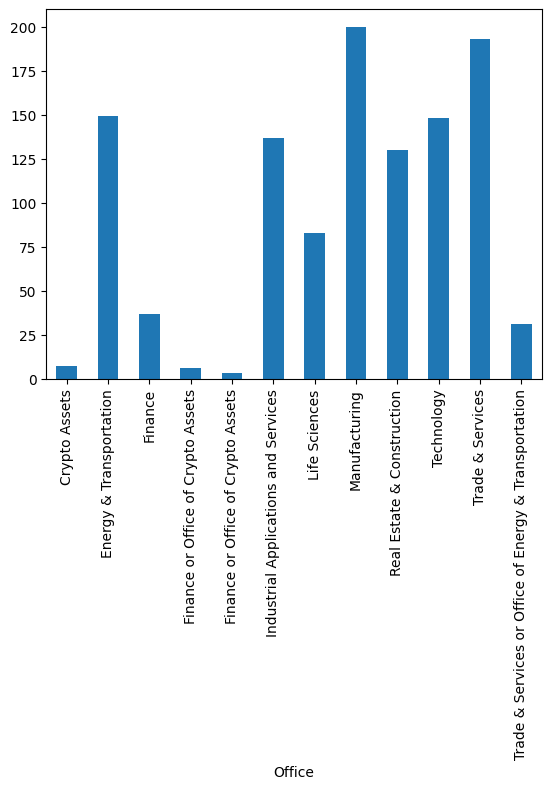

In [ ]:
# Plot a bar chart of each office count
import matplotlib.pyplot as plt
final_df.groupby('Office')['ticker'].nunique().plot(kind='bar')

plt.show()

There are clearly some opportunities to consolidate categories particularly with the finance and crypto categories which have only a handful of companies but are currently spread across 4 buckets. Overall, this chart shows that there is a decently large sample size of companies in each industry meaning there will be a healthy amount of intra-industry choice. This is an important consideration for my long-short strategy as often I would like to select two companies from the same industry.
One of the other metrics we can look at is the distribution of revenue across companies. 

This data set does not include market cap (although if desired it could be added later) so instead I used revenue as an indicator of company size. It was first necessary to log-transform the data because the range spans several orders of magnitude from single digit millions to triple digit billions. The below histogram shows the result of this transformation. 


c:\Users\tjbos\AppData\Local\Programs\Python\Python312\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


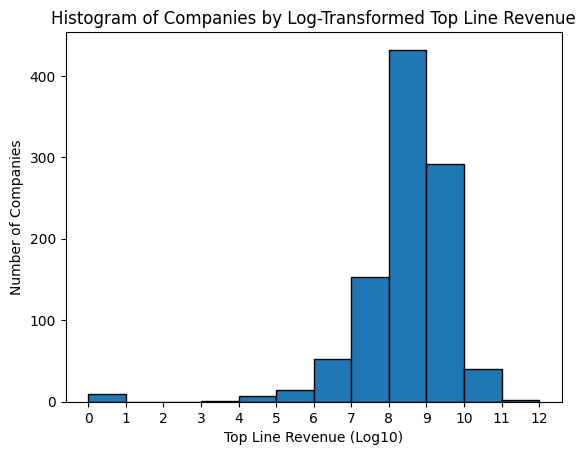

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Get most recent revenue for each ticker
most_recent_revenue_df = final_df.loc[final_df.groupby('ticker')['CurrentPeriodDate'].idxmax()]

# Prevent log issues: Set zero values to zero AFTER log transformation
most_recent_revenue_df['LogRevenue'] = np.where(
    most_recent_revenue_df['TopLineRevenue'] > 0, 
    np.log10(most_recent_revenue_df['TopLineRevenue']), 
    0  # Assign zero where revenue is zero
)

# Define bin edges based on min/max values
min_log = np.floor(most_recent_revenue_df['LogRevenue'].min())
max_log = np.ceil(most_recent_revenue_df['LogRevenue'].max())
bins = np.arange(min_log, max_log + 1, 1)  # Step size of 1 for even spacing

# Plot histogram
plt.hist(most_recent_revenue_df['LogRevenue'], bins=bins, edgecolor='black', align='mid')

# Set tick positions to match bin edges
plt.xticks(bins)

plt.xlabel('Top Line Revenue (Log10)')
plt.ylabel('Number of Companies')
plt.title('Histogram of Companies by Log-Transformed Top Line Revenue')

plt.show()

The log transformation helps immensely for visualizing the revenue distribution, at the expense of a little bit of interpretability. Taking an extra half second to analyze we can see that most companies fall between 100 million and 1 billion dollars with a decent chunk also being in the 1 to 10 billion dollar revenue range.

Now that we have an idea of some of the descriptive metrics, we would also like to know about variable relationships to each other to test for multicolinearity, and to the target variable to test for feature importance. Beginning with a simple unadulterated correlation matrix:

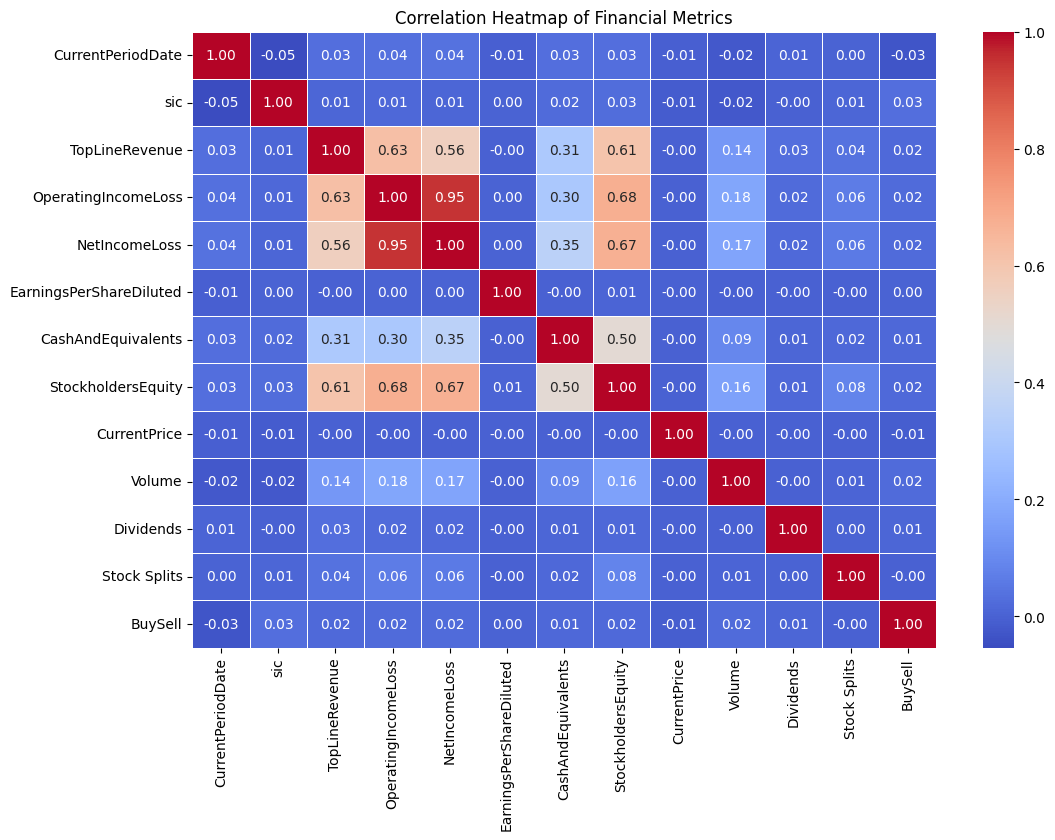

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Drop non-numeric columns (adjust if necessary)
numeric_df = final_df.select_dtypes(include=['number'])

numeric_df = numeric_df.drop(columns=['FuturePeriodDate', 'FuturePeriodPrice', 'PeriodLength', 'LogReturn', 'AvgMonthlyLogReturn'])
numeric_df.rename(columns={'CashAndCashEquivalentsAtCarryingValue': 'CashAndEquivalents'}, inplace=True)

# Compute correlation matrix
correlation_matrix = numeric_df.corr(method='pearson')

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Financial Metrics")
plt.show()

Yikes! Almost no variables are correlated with each other, and the BuySell target also has basically zero correlation with any of the other variables. In a vacuum this is a bit disheartening, but I am not giving up hope. Given the temporal nature of the data it is not unusual for the correlations to be minimal for each given data point. I will conduct one further test to check for feature importance relative to the target variable. Using mutual information classifier, we can see how much information variables contain about the state of the target. 

C:\Users\tjbos\AppData\Local\Temp\ipykernel_22300\2775866465.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Mutual Information', y='Feature', data=mi_df, palette='viridis')


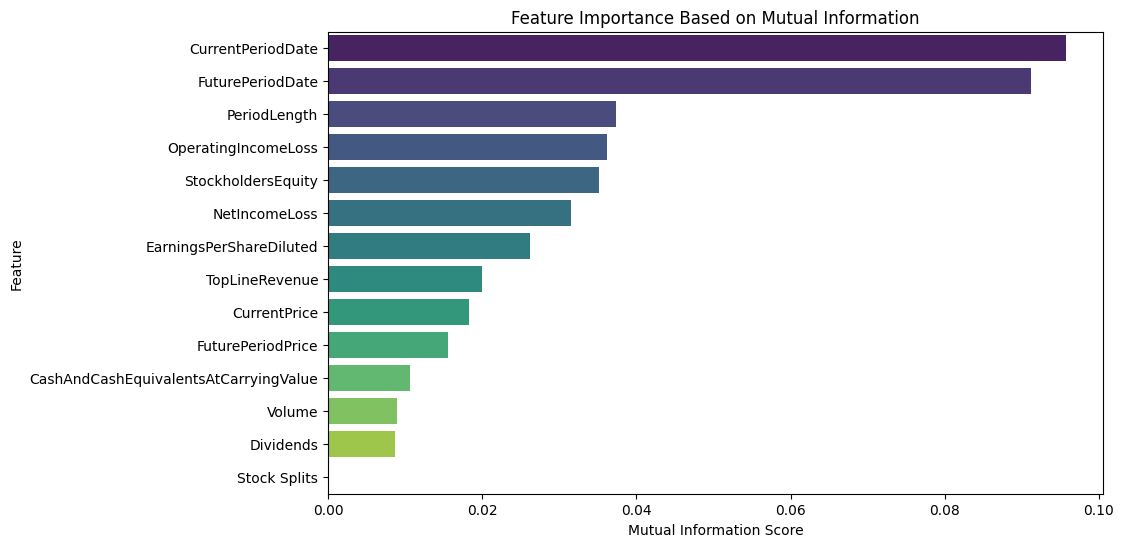

In [ ]:
import numpy as np
from sklearn.feature_selection import mutual_info_classif

features_df = final_df.copy()
features_df = features_df.dropna()
target_list = features_df['BuySell']
features_df = features_df.drop(columns=(['ticker','name', 'sic','Office','BuySell','AvgMonthlyLogReturn', 'LogReturn']))

mi_scores = mutual_info_classif(features_df, target_list, discrete_features=False)

# Create DataFrame for plotting
mi_df = pd.DataFrame({'Feature': features_df.columns, 'Mutual Information': mi_scores})

# Sort by importance
mi_df = mi_df.sort_values(by='Mutual Information', ascending=False)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Mutual Information', y='Feature', data=mi_df, palette='viridis')
plt.xlabel('Mutual Information Score')
plt.ylabel('Feature')
plt.title('Feature Importance Based on Mutual Information')
plt.show()


A score of 0.04 as the highest for a numeric variable is still not good. There is some promise that the date and lagged date provide some information. This proves that further feature engineering will definitely be necessary before any model can be built. 

# Feature Engineering & Initial Modeling

### Feature Engineering

In [ ]:
data_df = pd.read_csv('../data/clean/master_file_v2.csv')

In [ ]:
# Re-label any data point in the "Office" column that contains "Finance" or "Cyrpto" as just "Finance"

data_df["Office"] = data_df["Office"].replace("Finance or Office of Crypto Assets", "Finance")
data_df["Office"] = data_df["Office"].replace("Finance or\xa0Office of Crypto Assets", "Finance")
data_df["Office"] = data_df["Office"].replace("Crypto Assets", "Finance")
data_df["Office"] = data_df["Office"].replace("Trade & Services or Office of Energy & Transportation", "Trade & Services or Energy & Transportation")

Now we want to check the companies in the Trade & Services or Energy & Transportation to see which category they belong to.

In [ ]:
# Check what companies fall under this category to assign correctly
data_df.loc[data_df['Office']=="Trade & Services or Energy & Transportation", 'name'].unique()

array(['MASTERCARD INC', 'AKAMAI TECHNOLOGIES INC', 'GLOBAL PAYMENTS INC',
       'MSCI INC.', 'MAXIMUS INC', 'CBIZ, INC.', 'COSTAR GROUP INC',
       'MARCHEX INC', 'QUINSTREET, INC', 'XCEL BRANDS, INC.',
       'INOVA TECHNOLOGY INC.', 'B. RILEY FINANCIAL, INC.',
       'TRINET GROUP INC', 'HEALTHEQUITY INC',
       'BROADRIDGE FINANCIAL SOLUTIONS, INC.', 'ZILLOW GROUP, INC.',
       'DHI GROUP, INC.', 'EMERALD EXPOSITIONS EVENTS, INC.',
       'EXLSERVICE HOLDINGS, INC.', 'PAYPAL HOLDINGS, INC.',
       'RIMINI STREET, INC.', 'COMSCORE, INC.', 'WEX INC.',
       'INTERNATIONAL MONEY EXPRESS, INC.', 'EXP WORLD HOLDINGS, INC.',
       'MAXIMUS, INC.', 'TRINET GROUP, INC.', 'COSTAR GROUP, INC.',
       'HERITAGE GLOBAL INC.', 'HEALTHEQUITY, INC.',
       'EMERALD HOLDING, INC.', 'PAYMENTUS HOLDINGS, INC.',
       'STEEL CONNECT, INC.', '4LESS GROUP, INC.', 'REMITLY GLOBAL, INC.',
       'AUTO PARTS 4LESS GROUP, INC.', 'BLUEONE CARD, INC.'], dtype=object)

After checking it looks like all can safely be grouped into Trade & Services.

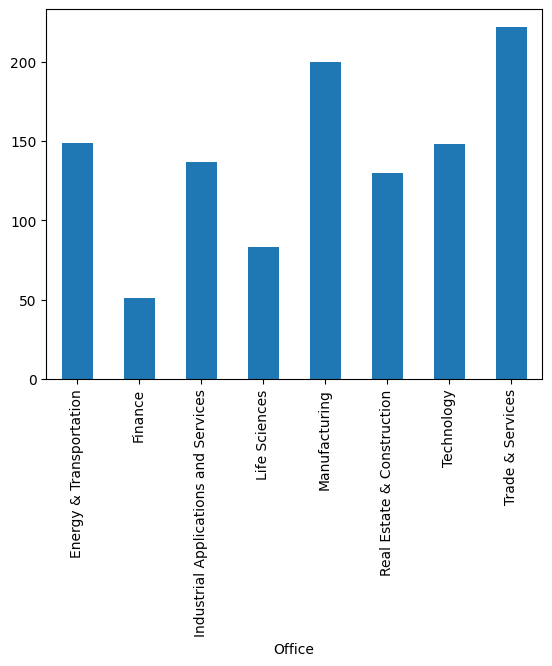

In [ ]:
data_df["Office"] = data_df["Office"].replace("Trade & Services or Energy & Transportation", "Trade & Services")

# Show a plot of the number of unique tickers by office
data_df.groupby('Office')['ticker'].nunique().plot(kind='bar')
plt.show()

Before moving into preliminary modeling, I engineered lag features of each fundamental variable to help show the time series nature of the data.

In [ ]:
# Drop columns that we don't need at the moment
# We aren't going to drop the leakage columns until right before modeling step
drop_cols1 = ['Stock Splits', 'Dividends']

engineer_df = data_df.copy()
engineer_df = pd.DataFrame(engineer_df.drop(columns=drop_cols1))

# Engineer lag variables for each Fundamental variable
columns = ['TopLineRevenue', 'OperatingIncomeLoss', 'NetIncomeLoss',
            'EarningsPerShareDiluted', 'CashAndCashEquivalentsAtCarryingValue',
            'StockholdersEquity']

for column in columns:
    engineer_df[f'{column}_lag1'] = engineer_df.groupby('ticker')[f'{column}'].shift(1)


### Initial Modeling

As I moved to the analysis phase of this project, I began performing a bit more refined feature engineering. I kept a one period lagged version of each financial metric feature and added a 3-period moving average of each. More features which I included in the data set for my best model thus far are financial ratio metrics, and a numerical encoding of stock tickers. Creating all these features requires taking care to prevent data leakage between the training, validation, and test sets.
As this is a multiclass classification problem, I will be using models that are designed for this task. 

To begin I will use a simple decision tree to get a benchmark performance level. I will then move to more complex ensembles, namely XGBoost. To evaluate performance of these models, I will use F1 score which is appropriate because our problem is concerned with both stocks to buy and stocks to sell therefore having both high precision and high recall is important.

Once this initial data set was formed and free of leakage, I ran a simple decision tree to get an idea of baseline performance and used 5 time series folds in a cross-fold validation. The performance on this first go around was decidedly poor, yielding an average F1 score of just 0.24 across folds.


In [ ]:
# Create the model df which drops the leakage columns

model_df = engineer_df.copy()

drop_cols2 = ['FuturePeriodDate', 'FuturePeriodPrice', 'LogReturn', 'AvgMonthlyLogReturn']
model_df = model_df.drop(columns=drop_cols2)

In [ ]:
# Train a baseline model in the absolute simplest manner, essentially ignoring ticker 
# and simply trying to predict the target strong buy to strong sell

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import f1_score


# Drop N/A for this model to work (not necessary when eventually moving to XGBoost)
model_df = model_df.dropna()

# Define the target variable
y = model_df['BuySell']

# Drop the target column from model_df to get the features
X = model_df.drop(columns=['BuySell'])
X = pd.get_dummies(X)

tscv = TimeSeriesSplit(n_splits=5) # Adjust n_splits as needed

for train_index, test_index in tscv.split(model_df): # X is your time series data
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index] # y is your target variable

    # Train your decision tree model
    model = DecisionTreeClassifier()
    model.fit(X_train, y_train)

    # Make predictions
    y_pred = model.predict(X_test)

    # Evaluate the model
    f1 = f1_score(y_test, y_pred, average='weighted')
    print(f"Fold F1 score: {f1}")


Fold F1 score: 0.24895959600670417
Fold F1 score: 0.243652908010854
Fold F1 score: 0.24042456715499697
Fold F1 score: 0.24002596828369704
Fold F1 score: 0.2622436003420207


The above approach one-hot-encoded all tickers as binary features, which creates too much dimensionality for the model to perform well. The following approach instead encodes the tickers based on teh average of their NetIncomeLoss.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import f1_score

# Drop N/A (for this simple model, but XGBoost can handle them later)
model_df = model_df.dropna().reset_index(drop=True)

# Define target and features
y = model_df['BuySell']
X = model_df.drop(columns=['BuySell'])

# Time-based cross-validation
tscv = TimeSeriesSplit(n_splits=5) 

# Store F1 scores for each fold
f1_scores = []

for fold, (train_index, test_index) in enumerate(tscv.split(model_df)):
    print(f"Processing Fold {fold + 1}...")

    # Split data
    X_train, X_test = X.iloc[train_index].copy(), X.iloc[test_index].copy()
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Compute average NetIncomeLoss per ticker (using only training data)
    ticker_avg = X_train.groupby('ticker')['NetIncomeLoss'].mean()

    # Encode ticker using NetIncomeLoss averages
    X_train['ticker_NIL_encoded'] = X_train['ticker'].map(ticker_avg)
    X_test['ticker_NIL_encoded'] = X_test['ticker'].map(ticker_avg)

    # Handle unseen tickers in test set by filling with global mean NetIncomeLoss
    global_avg = X_train['NetIncomeLoss'].mean()
    X_test['ticker_NIL_encoded'].fillna(global_avg, inplace=True)

    # Drop non-numeric columns (excluding 'Office' if it's meaningful)
    X_train.drop(columns=['ticker', 'name'], inplace=True)
    X_test.drop(columns=['ticker', 'name'], inplace=True)

    # Convert categorical variables to dummies
    X_train = pd.get_dummies(X_train)
    X_test = pd.get_dummies(X_test)

    # Ensure train and test sets have the same columns
    X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

    # Initialize Decision Tree with regularization
    model = DecisionTreeClassifier(max_depth=5, min_samples_split=10, random_state=42)
    model.fit(X_train, y_train)

    # Make predictions
    y_pred = model.predict(X_test)

    # Evaluate the model
    f1 = f1_score(y_test, y_pred, average='macro')
    f1_scores.append(f1)
    print(f"Fold {fold + 1} F1 score: {f1:.4f}")

# Print overall performance
print(f"\nAverage F1 Score: {np.mean(f1_scores):.4f}")



Processing Fold 1...
Fold 1 F1 score: 0.2527
Processing Fold 2...


C:\Users\tjbos\AppData\Local\Temp\ipykernel_22300\2482411151.py:36: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_test['ticker_NIL_encoded'].fillna(global_avg, inplace=True)
C:\Users\tjbos\AppData\Local\Temp\ipykernel_22300\2482411151.py:36: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a

Fold 2 F1 score: 0.2088
Processing Fold 3...


C:\Users\tjbos\AppData\Local\Temp\ipykernel_22300\2482411151.py:36: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_test['ticker_NIL_encoded'].fillna(global_avg, inplace=True)


Fold 3 F1 score: 0.2110
Processing Fold 4...


C:\Users\tjbos\AppData\Local\Temp\ipykernel_22300\2482411151.py:36: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_test['ticker_NIL_encoded'].fillna(global_avg, inplace=True)


Fold 4 F1 score: 0.2124
Processing Fold 5...


C:\Users\tjbos\AppData\Local\Temp\ipykernel_22300\2482411151.py:36: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_test['ticker_NIL_encoded'].fillna(global_avg, inplace=True)


Fold 5 F1 score: 0.1648

Average F1 Score: 0.2099


This still didn't do much to improve our F1 score, if anything it got slightly worse. I am going to claim 0.2 as our benchmark F1 score. This is quite low, and a score of at least 0.5 would be the goal. Below I attempt to use this encoding strategy on XGBoost, a more advanced ensemble model. This model will no longer perform the strange cross-fold validation like the previous one, instead it will be split manually to ensure integrity of time series nature.

In [ ]:
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score

# Let's define a new df to work from
xg_df = engineer_df.copy()
xg_df = xg_df.drop(columns=['FuturePeriodDate', 
                            'FuturePeriodPrice', 
                            'LogReturn', 
                            'AvgMonthlyLogReturn',
                            'TopLineRevenue_lag1',
                            'OperatingIncomeLoss_lag1',
                            'NetIncomeLoss_lag1',
                            'EarningsPerShareDiluted_lag1',
                            'CashAndCashEquivalentsAtCarryingValue_lag1',
                            'StockholdersEquity_lag1'])

xg_df = xg_df.sort_values(by=['CurrentPeriodDate','ticker'])

#Add the moving averages
for column in columns:
   xg_df[f"{column}_MA3"] = xg_df.groupby('ticker')[f"{column}"].transform(lambda x: x.rolling(window=3).mean().shift(1))

# Reset the index to ensure alignment
xg_df = xg_df.reset_index(drop=True)

# Set up the train_val_test split
# Determine the split point
train_size = int(len(xg_df) * 0.6)

# Split the data
train_df = xg_df[:train_size]
temp_df = xg_df[train_size:]

test_size = int(len(temp_df) * 0.5)

val_df = temp_df[:test_size]
test_df = temp_df[test_size:]

### ADDING MOVING AVERAGES FEATURES ###
# Add the moving averages separately for each split to avoid data leakage
for column in columns:
    train_df[f"{column}_MA3"] = train_df.groupby('ticker')[f"{column}"].transform(lambda x: x.rolling(window=3).mean().shift(1))
    val_df[f"{column}_MA3"] = val_df.groupby('ticker')[f"{column}"].transform(lambda x: x.rolling(window=3).mean().shift(1))
    test_df[f"{column}_MA3"] = test_df.groupby('ticker')[f"{column}"].transform(lambda x: x.rolling(window=3).mean().shift(1))

# Drop rows with NaN values created by the rolling mean
train_df = train_df.dropna()
val_df = val_df.dropna()
test_df = test_df.dropna()

### ENCODE THE TICKER NIL ENCODING ###
# Compute the average NetIncomeLoss per ticker in the training set only
ticker_avg = train_df.groupby('ticker')['NetIncomeLoss'].mean()

# Apply encoding to training data
train_df['ticker_encoded'] = train_df['ticker'].map(ticker_avg)

# Apply encoding to val and test data using only values from the training set
val_df['ticker_encoded'] = val_df['ticker'].map(ticker_avg)
test_df['ticker_encoded'] = test_df['ticker'].map(ticker_avg)

# Handle unseen tickers in test data by filling with the global mean NetIncomeLoss
global_avg = train_df['NetIncomeLoss'].mean()
val_df['ticker_encoded'].fillna(global_avg, inplace=True)
test_df['ticker_encoded'].fillna(global_avg, inplace=True)


### SET UP THE MODEL FOR TRAINING ###
target = 'BuySell'
X_train = train_df.drop(columns=[target,'ticker','name','Office'])
y_train = train_df[target]

X_val = val_df.drop(columns=[target,'ticker','name','Office'])
y_val = val_df[target]
X_test = test_df.drop(columns=[target,'ticker','name','Office'])
y_test = test_df[target]
# One-hot encode categorical variables if necessary
X_train = pd.get_dummies(X_train)
X_val = pd.get_dummies(X_val)
X_test = pd.get_dummies(X_test)
# Align the columns of validation and test sets with the training set
X_val = X_val.reindex(columns=X_train.columns, fill_value=0)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

### TESTING THE MODEL ###

# Define XGBoost model
xgb = XGBClassifier(
    objective='multi:softmax',  # Multiclass classification
    num_class=5,  # Since you have Buy/Sell ratings (-2 to 2)
    eval_metric='mlogloss',  # Multi-class log loss
)

# Shift labels from [-2, -1, 0, 1, 2] to [0, 1, 2, 3, 4]
y_shifted = y + 2  # This makes -2 → 0, -1 → 1, 0 → 2, etc.

# Train the model using y_shifted instead of y
xgb.fit(X_train, y_train + 2)
y_pred = xgb.predict(X_val)

# Convert predictions back to original scale
y_pred_original = y_pred - 2

 # Evaluate the model
val_f1 = f1_score(y_val, y_pred_original, average='weighted')
print(f"F1 score: {val_f1}")

C:\Users\tjbos\AppData\Local\Temp\ipykernel_22300\2224928573.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df[f"{column}_MA3"] = train_df.groupby('ticker')[f"{column}"].transform(lambda x: x.rolling(window=3).mean().shift(1))
C:\Users\tjbos\AppData\Local\Temp\ipykernel_22300\2224928573.py:44: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  val_df[f"{column}_MA3"] = val_df.groupby('ticker')[f"{column}"].transform(lambda x: x.rolling(window=3).mean().shift(1))
C:\Users\tjbos\AppData\Local\Temp\ipyk

F1 score: 0.19836694054643353


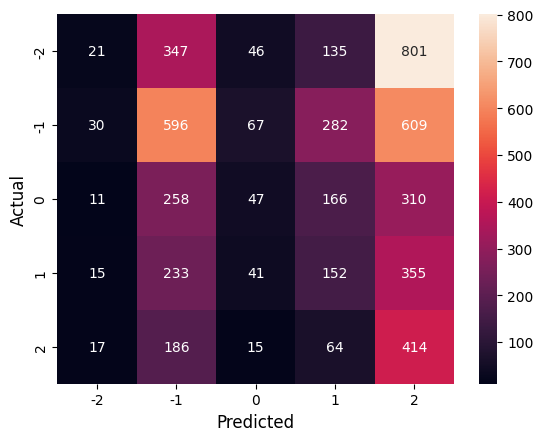

In [ ]:
# Make a visual of the predictions
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_val, y_pred_original)

original_classes = [label - 2 for label in xgb.classes_]

sns.heatmap(cm, annot=True, fmt='g', xticklabels=original_classes, yticklabels=original_classes)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.show()

The F1 score is also ~0.2 for the XGBoost model, so no improvement yet over the decision tree. Furthermore, the confusion matrix is a mess, particularly a value of 2 being predicted where the actual was -2. In the final model we absolutely want to avoid this, in its current state it cannot be trusted to select stocks.

In [ ]:
# Encode the variables as a comparison to prior period rather than strictly numeric. 
# Now we are encoding temporal nature, theoretically could increase performance

new_df = xg_df.copy()

for column in columns:
    new_df[f"{column}_vs_prior"] = new_df.groupby('ticker')[f"{column}"].diff()

new_df = new_df.sort_values(by=['ticker'])

# Now run the model on the new_df

# Set up the train_val_test split
# Determine the split point
train_size = int(len(new_df) * 0.6)

# Split the data
train_df = new_df[:train_size]
temp_df = new_df[train_size:]

test_size = int(len(temp_df) * 0.5)

val_df = temp_df[:test_size]
test_df = temp_df[test_size:]

# Drop rows with NaN values created by the rolling mean
train_df = train_df.dropna()
val_df = val_df.dropna()
test_df = test_df.dropna()

### ENCODE THE TICKER NIL ENCODING ###
# Compute the average NetIncomeLoss per ticker in the training set only
ticker_avg = train_df.groupby('ticker')['NetIncomeLoss'].mean()

# Apply encoding to training data
train_df['ticker_encoded'] = train_df['ticker'].map(ticker_avg)

# Apply encoding to val and test data using only values from the training set
val_df['ticker_encoded'] = val_df['ticker'].map(ticker_avg)
test_df['ticker_encoded'] = test_df['ticker'].map(ticker_avg)

# Handle unseen tickers in test data by filling with the global mean NetIncomeLoss
global_avg = train_df['NetIncomeLoss'].mean()
val_df['ticker_encoded'].fillna(global_avg, inplace=True)
test_df['ticker_encoded'].fillna(global_avg, inplace=True)


### SET UP THE MODEL FOR TRAINING ###
target = 'BuySell'
X_train = train_df.drop(columns=[target,'ticker','name','Office'])
y_train = train_df[target]

X_val = val_df.drop(columns=[target,'ticker','name','Office'])
y_val = val_df[target]
X_test = test_df.drop(columns=[target,'ticker','name','Office'])
y_test = test_df[target]
# One-hot encode categorical variables if necessary
X_train = pd.get_dummies(X_train)
X_val = pd.get_dummies(X_val)
X_test = pd.get_dummies(X_test)
# Align the columns of validation and test sets with the training set
X_val = X_val.reindex(columns=X_train.columns, fill_value=0)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

### TESTING THE MODEL ###

# Define XGBoost model
xgb = XGBClassifier(
    objective='multi:softmax',  # Multiclass classification
    num_class=5,  # Since you have Buy/Sell ratings (-2 to 2)
    eval_metric='mlogloss',  # Multi-class log loss
)

# Shift labels from [-2, -1, 0, 1, 2] to [0, 1, 2, 3, 4]
y_shifted = y + 2  # This makes -2 → 0, -1 → 1, 0 → 2, etc.

# Train the model using y_shifted instead of y
xgb.fit(X_train, y_train + 2)
y_pred = xgb.predict(X_val)

# Convert predictions back to original scale
y_pred_original = y_pred - 2

 # Evaluate the model
val_f1 = f1_score(y_val, y_pred_original, average='weighted')
print(f"F1 score: {val_f1}")

C:\Users\tjbos\AppData\Local\Temp\ipykernel_22300\4051589208.py:44: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  val_df['ticker_encoded'].fillna(global_avg, inplace=True)
C:\Users\tjbos\AppData\Local\Temp\ipykernel_22300\4051589208.py:45: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a cop

F1 score: 0.3126996635050395


Adding features that show the comparison vs prior period has increased the performance significantly over the previous version, but it is still not good. Another idea is to add financial ratios as features and remove the raw income statement data because so far it hasn't done us any good. We can then go one further on this and show the *change* in the ratios from one period to the next. Ratios also might help to normalize the data.

In [ ]:
# Create features for P/E (price/EPSD), profit margin (Bottom/Top), and ROE (net income / shareholder's equity)

ratio_df = new_df.copy()

ratio_df['PE_ratio'] = ratio_df['CurrentPrice'] / ratio_df['EarningsPerShareDiluted']
ratio_df['profit_margin'] = ratio_df['NetIncomeLoss'] / ratio_df['TopLineRevenue']
ratio_df['ROE'] = ratio_df['NetIncomeLoss'] / ratio_df['StockholdersEquity']


# Replace infinite values with 0
ratio_df.replace([float('inf'), float('-inf')], 0, inplace=True)

# Now run the model on the ratio_df

from sklearn.metrics import f1_score, precision_score, recall_score

# Set up the train_val_test split
# Determine the split point
train_size = int(len(ratio_df) * 0.6)

# Split the data
train_df = ratio_df[:train_size]
temp_df = ratio_df[train_size:]

test_size = int(len(temp_df) * 0.5)

val_df = temp_df[:test_size]
test_df = temp_df[test_size:]

# Drop rows with NaN values created by the rolling mean
train_df = train_df.dropna()
val_df = val_df.dropna()
test_df = test_df.dropna()

### ENCODE THE TICKER NIL ENCODING ###
# Compute the average NetIncomeLoss per ticker in the training set only
ticker_avg = train_df.groupby('ticker')['NetIncomeLoss'].mean()

# Apply encoding to training data
train_df['ticker_encoded'] = train_df['ticker'].map(ticker_avg)

# Apply encoding to val and test data using only values from the training set
val_df['ticker_encoded'] = val_df['ticker'].map(ticker_avg)
test_df['ticker_encoded'] = test_df['ticker'].map(ticker_avg)

# Handle unseen tickers in test data by filling with the global mean NetIncomeLoss
global_avg = train_df['NetIncomeLoss'].mean()
val_df['ticker_encoded'].fillna(global_avg, inplace=True)
test_df['ticker_encoded'].fillna(global_avg, inplace=True)


### SET UP THE MODEL FOR TRAINING ###
target = 'BuySell'
X_train = train_df.drop(columns=[target,'ticker','name','Office'])
y_train = train_df[target]

X_val = val_df.drop(columns=[target,'ticker','name','Office'])
y_val = val_df[target]
X_test = test_df.drop(columns=[target,'ticker','name','Office'])
y_test = test_df[target]
# One-hot encode categorical variables if necessary
X_train = pd.get_dummies(X_train)
X_val = pd.get_dummies(X_val)
X_test = pd.get_dummies(X_test)
# Align the columns of validation and test sets with the training set
X_val = X_val.reindex(columns=X_train.columns, fill_value=0)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

### TESTING THE MODEL ###

# Define XGBoost model
xgb = XGBClassifier(
    objective='multi:softmax',  # Multiclass classification
    num_class=5,  # Since you have Buy/Sell ratings (-2 to 2)
    eval_metric='mlogloss',  # Multi-class log loss
)

# Shift labels from [-2, -1, 0, 1, 2] to [0, 1, 2, 3, 4]
y_shifted = y + 2  # This makes -2 → 0, -1 → 1, 0 → 2, etc.

# Train the model using y_shifted instead of y
xgb.fit(X_train, y_train + 2)
y_pred = xgb.predict(X_val)

# Convert predictions back to original scale
y_pred_original = y_pred - 2

 # Evaluate the model
val_f1 = f1_score(y_val, y_pred_original, average='weighted')


print(f"F1 score: {val_f1}")


C:\Users\tjbos\AppData\Local\Temp\ipykernel_22300\1264663568.py:48: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  val_df['ticker_encoded'].fillna(global_avg, inplace=True)
C:\Users\tjbos\AppData\Local\Temp\ipykernel_22300\1264663568.py:49: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a cop

F1 score: 0.3056124340092329


This actually made the performance slighly worse, but really it didn't change much. Like previously, I am also going to show the difference in the ratio vs its prior period.

In [ ]:
# Encode the variables as a comparison to prior period rather than strictly numeric. 

ratio_df_delta = ratio_df.copy()

ratios = ('PE_ratio','profit_margin', 'ROE')

for ratio in ratios:
    ratio_df_delta[f"{ratio}_vs_prior"] = ratio_df_delta.groupby('ticker')[f"{ratio}"].diff()

ratio_df_delta = ratio_df_delta.sort_values(by=['ticker'])
ratio_df_delta.head(5)

# Now run the model on the ratio_df_delta

from sklearn.metrics import multilabel_confusion_matrix

# Set up the train_val_test split
# Determine the split point
train_size = int(len(ratio_df_delta) * 0.6)

# Split the data
train_df = ratio_df_delta[:train_size]
temp_df = ratio_df_delta[train_size:]

test_size = int(len(temp_df) * 0.5)

val_df = temp_df[:test_size]
test_df = temp_df[test_size:]

# Drop rows with NaN values created by the rolling mean
train_df = train_df.dropna()
val_df = val_df.dropna()
test_df = test_df.dropna()

### ENCODE THE TICKER NIL ENCODING ###
# Compute the average NetIncomeLoss per ticker in the training set only
ticker_avg = train_df.groupby('ticker')['NetIncomeLoss'].mean()

# Apply encoding to training data
train_df['ticker_encoded'] = train_df['ticker'].map(ticker_avg)

# Apply encoding to val and test data using only values from the training set
val_df['ticker_encoded'] = val_df['ticker'].map(ticker_avg)
test_df['ticker_encoded'] = test_df['ticker'].map(ticker_avg)

# Handle unseen tickers in test data by filling with the global mean NetIncomeLoss
global_avg = train_df['NetIncomeLoss'].mean()
val_df['ticker_encoded'].fillna(global_avg, inplace=True)
test_df['ticker_encoded'].fillna(global_avg, inplace=True)


### SET UP THE MODEL FOR TRAINING ###
target = 'BuySell'
X_train = train_df.drop(columns=[target,'ticker','name','Office'])
y_train = train_df[target]

X_val = val_df.drop(columns=[target,'ticker','name','Office'])
y_val = val_df[target]
X_test = test_df.drop(columns=[target,'ticker','name','Office'])
y_test = test_df[target]
# One-hot encode categorical variables if necessary
X_train = pd.get_dummies(X_train)
X_val = pd.get_dummies(X_val)
X_test = pd.get_dummies(X_test)
# Align the columns of validation and test sets with the training set
X_val = X_val.reindex(columns=X_train.columns, fill_value=0)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

### TESTING THE MODEL ###

# Define XGBoost model
xgb = XGBClassifier(
    objective='multi:softmax',  # Multiclass classification
    num_class=5,  # Since you have Buy/Sell ratings (-2 to 2)
    eval_metric='mlogloss',  # Multi-class log loss
)

# Shift labels from [-2, -1, 0, 1, 2] to [0, 1, 2, 3, 4]
y_shifted = y + 2  # This makes -2 → 0, -1 → 1, 0 → 2, etc.

# Train the model using y_shifted instead of y
xgb.fit(X_train, y_train + 2)
y_pred = xgb.predict(X_val)

# Convert predictions back to original scale
y_pred_original = y_pred - 2

 # Evaluate the model
val_f1 = f1_score(y_val, y_pred_original, average='weighted')
precision = precision_score(y_val, y_pred_original, average='weighted')
recall = recall_score(y_val, y_pred_original, average='weighted')
cf = multilabel_confusion_matrix(y_val, y_pred_original)

print(f"F1 score: {val_f1}")
print(f"precision: {precision}")
print(f"recall: {recall}")
print(cf)

C:\Users\tjbos\AppData\Local\Temp\ipykernel_22300\83830333.py:48: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  val_df['ticker_encoded'].fillna(global_avg, inplace=True)
C:\Users\tjbos\AppData\Local\Temp\ipykernel_22300\83830333.py:49: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.



F1 score: 0.3125237637244397
precision: 0.3431046858889015
recall: 0.3283987505093033
[[[5612  286]
  [1156  309]]

 [[3989 1485]
  [1128  761]]

 [[5875  363]
  [1018  107]]

 [[4813 1166]
  [ 949  435]]

 [[4218 1645]
  [ 694  806]]]


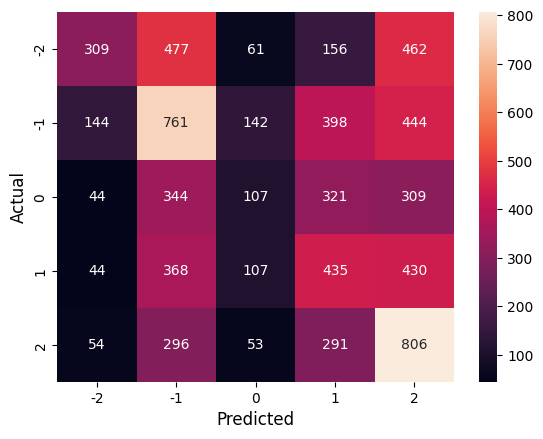

In [ ]:
# Make a visual of the predictions
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_val, y_pred_original)

original_classes = [label - 2 for label in xgb.classes_]

sns.heatmap(cm, annot=True, fmt='g', xticklabels=original_classes, yticklabels=original_classes)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.show()

An F1 score of 0.3125 is the same as the level before any of the ratios were added, so they don't seem to be helping very much right now. Seeing as they aren't hurting either, I am going to leave them in. It is very clear at this point that the research question will need to be revised, and that the model revision will likely need to take a different direction. 

Also, for good measure, let's run one test of this final ratio_df_delta with a decision tree model to confirm that XGBoost is the model we should continue to use going forward.

In [ ]:
# Testing how a decision tree performs on the same data
from sklearn.metrics import multilabel_confusion_matrix

# Set up the train_val_test split
# Determine the split point
train_size = int(len(ratio_df_delta) * 0.6)

# Split the data
train_df = ratio_df_delta[:train_size]
temp_df = ratio_df_delta[train_size:]

test_size = int(len(temp_df) * 0.5)

val_df = temp_df[:test_size]
test_df = temp_df[test_size:]

# Drop rows with NaN values created by the rolling mean
train_df = train_df.dropna()
val_df = val_df.dropna()
test_df = test_df.dropna()

### ENCODE THE TICKER NIL ENCODING ###
# Compute the average NetIncomeLoss per ticker in the training set only
ticker_avg = train_df.groupby('ticker')['NetIncomeLoss'].mean()

# Apply encoding to training data
train_df['ticker_encoded'] = train_df['ticker'].map(ticker_avg)

# Apply encoding to val and test data using only values from the training set
val_df['ticker_encoded'] = val_df['ticker'].map(ticker_avg)
test_df['ticker_encoded'] = test_df['ticker'].map(ticker_avg)

# Handle unseen tickers in test data by filling with the global mean NetIncomeLoss
global_avg = train_df['NetIncomeLoss'].mean()
val_df['ticker_encoded'].fillna(global_avg, inplace=True)
test_df['ticker_encoded'].fillna(global_avg, inplace=True)


### SET UP THE MODEL FOR TRAINING ###
target = 'BuySell'
X_train = train_df.drop(columns=[target,'ticker','name','Office'])
y_train = train_df[target]

X_val = val_df.drop(columns=[target,'ticker','name','Office'])
y_val = val_df[target]
X_test = test_df.drop(columns=[target,'ticker','name','Office'])
y_test = test_df[target]
# One-hot encode categorical variables if necessary
X_train = pd.get_dummies(X_train)
X_val = pd.get_dummies(X_val)
X_test = pd.get_dummies(X_test)
# Align the columns of validation and test sets with the training set
X_val = X_val.reindex(columns=X_train.columns, fill_value=0)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

### TESTING THE MODEL ###

# Define Decision Tree model
dt = DecisionTreeClassifier()

# Shift labels from [-2, -1, 0, 1, 2] to [0, 1, 2, 3, 4]
y_shifted = y + 2  # This makes -2 → 0, -1 → 1, 0 → 2, etc.

# Train the model using y_shifted instead of y
dt.fit(X_train, y_train + 2)
y_pred = dt.predict(X_val)

# Convert predictions back to original scale
y_pred_original = y_pred - 2

 # Evaluate the model
val_f1 = f1_score(y_val, y_pred_original, average='weighted')
precision = precision_score(y_val, y_pred_original, average='weighted')
recall = recall_score(y_val, y_pred_original, average='weighted')
cf = multilabel_confusion_matrix(y_val, y_pred_original)

print(f"F1 score: {val_f1}")
print(f"precision: {precision}")
print(f"recall: {recall}")
print(cf)

C:\Users\tjbos\AppData\Local\Temp\ipykernel_22300\110874885.py:35: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  val_df['ticker_encoded'].fillna(global_avg, inplace=True)
C:\Users\tjbos\AppData\Local\Temp\ipykernel_22300\110874885.py:36: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

F1 score: 0.2742433778059741
precision: 0.27622240337330906
recall: 0.27339399701208744
[[[5018  880]
  [1075  390]]

 [[4247 1227]
  [1297  592]]

 [[5257  981]
  [ 928  197]]

 [[4786 1193]
  [ 991  393]]

 [[4794 1069]
  [1059  441]]]


An F1 score of 0.2725 is slightly worse than XGBoost, so going forward I will use XGBoost as my primary model.

# Final Research Question

The objective of my research is to develop a model which selects stocks to put in a long-short equities portfolio and has a better risk adjusted return than the market. This approach hedges market risk (downturns) providing a stable return during all market conditions.

After looking at the poor performance above, I subconsciously scaled back the reach of my research question, simplifying the short-term goals of the project for the sake of better long-term outcomes. My previous research question sought to create a portfolio. However, my current research question is to classify stocks based on whether their price will rise or fall over the coming 3-month period, and by how strong of a magnitude. This is a multiclass classification machine learning problem with target variable ‘BuySell’ and values strong-buy, buy, hold, sell, strong-sell, encoded as 2 to -2. If this initial classification problem can be solved, it will enable us to tackle the broader problem of creating a market neutral long-short portfolio.

Even after scaling back the question to this degree, my model simply is unable to perform adequately. The final evolution of my research question is no longer going to look at things through a multiclass lens, but simplify down to a binary case of buy sell. The goal is now to build a machine learning model which can predict whether to buy or sell a stock where success is measured by achieving an F1 score greater than 0.5.


# Model Revision

In [ ]:
# Read in the data
data_df = pd.read_csv('../data/clean/master_file_v2.csv')

# Since we don't have an updated version of the file,
# we will perform the same initial data cleaning steps as before

# Re-label any data point in the "Office" column that contains "Finance" or "Cyrpto" as just "Finance"

data_df["Office"] = data_df["Office"].replace("Finance or Office of Crypto Assets", "Finance")
data_df["Office"] = data_df["Office"].replace("Finance or\xa0Office of Crypto Assets", "Finance")
data_df["Office"] = data_df["Office"].replace("Crypto Assets", "Finance")
data_df["Office"] = data_df["Office"].replace("Trade & Services or Office of Energy & Transportation", "Trade & Services")

# Drop columns that we don't need at the moment
# We aren't going to drop the leakage columns until right before modeling step
drop_cols1 = ['Stock Splits', 'Dividends']

engineer_df = data_df.copy()
engineer_df = pd.DataFrame(engineer_df.drop(columns=drop_cols1))

# Check the median of AvgMonthlyLogReturn

engineer_df['AvgMonthlyLogReturn'].median()


0.0064204942829369505

In [ ]:
# Update BuySell to be binary 1 = buy for AvgMonthlyLogReturn > 0.0064, 0 = sell for AvgMonthlyLogReturn < 0.0064
engineer_df['BuySell'] = engineer_df['AvgMonthlyLogReturn'].apply(lambda x: 1 if x > 0.0064 else 0)

# Check the distribution of BuySell
engineer_df['BuySell'].value_counts()

BuySell
0    20415
1    20324
Name: count, dtype: int64

In [ ]:
# Create the model_df which drops the leakage columns

model_df = engineer_df.copy()

drop_cols2 = ['FuturePeriodDate', 'FuturePeriodPrice', 'PeriodLength','LogReturn', 'AvgMonthlyLogReturn']
model_df = model_df.drop(columns=drop_cols2)

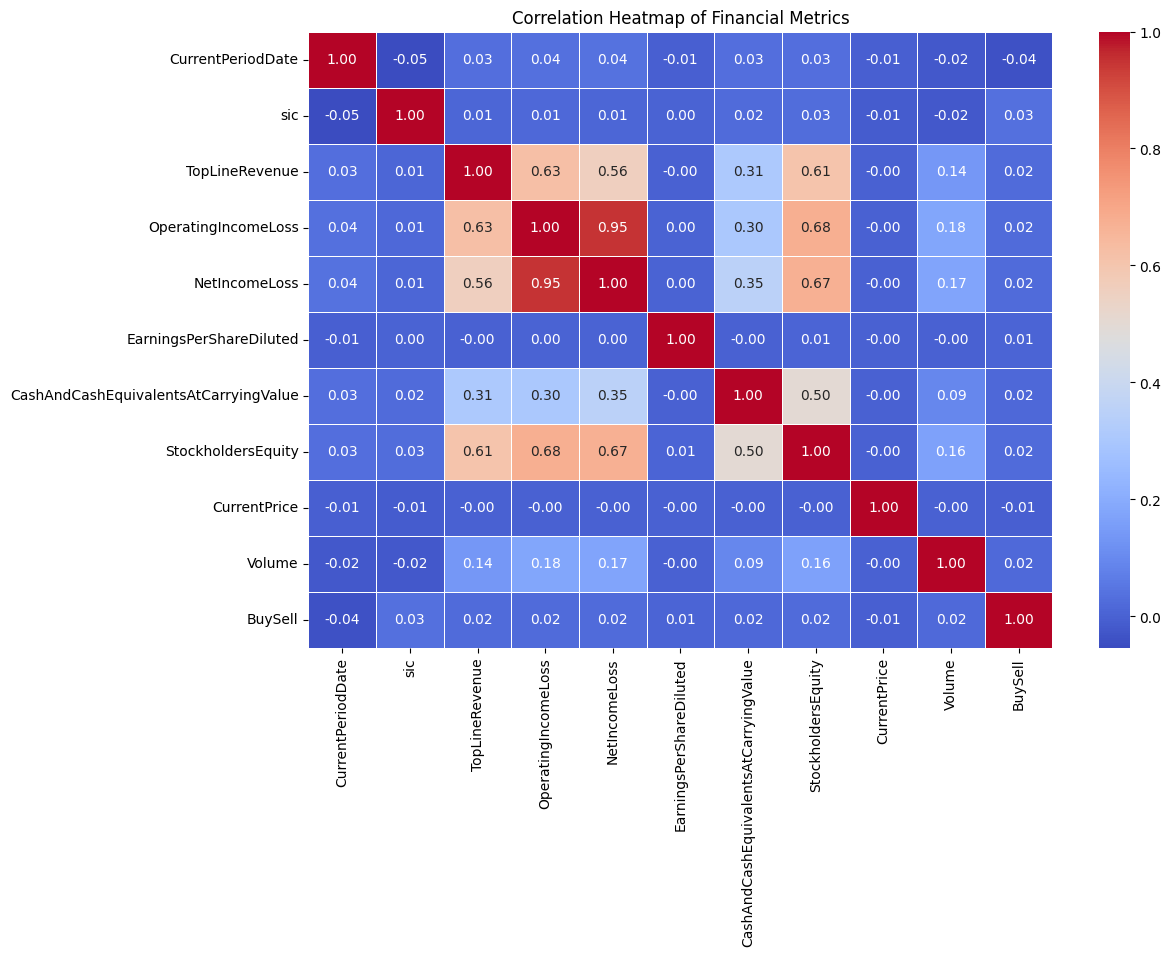

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Drop non-numeric columns (adjust if necessary)
numeric_df = model_df.select_dtypes(include=['number'])

# Compute correlation matrix
correlation_matrix = numeric_df.corr(method='pearson')

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Financial Metrics")
plt.show()

Now that we have the data staged for modeling, below will run preliminary tests of common classifiers

In [ ]:
### Stage the data for modeling ###

from sklearn.metrics import f1_score

logreg_df = model_df.copy()
logreg_df = logreg_df.sort_values(by=['CurrentPeriodDate','ticker'])


### SET UP THE train_val_test SPLIT ###
# Determine the split point
train_size = int(len(logreg_df) * 0.6)

# Split the data
train_df = logreg_df[:train_size]
temp_df = logreg_df[train_size:]

test_size = int(len(temp_df) * 0.5)

val_df = temp_df[:test_size]
test_df = temp_df[test_size:]


### ENCODE THE TICKER NIL ENCODING ###
# Compute the average NetIncomeLoss per ticker in the training set only
ticker_avg = train_df.groupby('ticker')['NetIncomeLoss'].mean()

# Apply encoding to training data
train_df.loc[:, 'ticker_encoded'] = train_df['ticker'].map(ticker_avg)

# Apply encoding to val and test data using only values from the training set
val_df.loc[:, 'ticker_encoded'] = val_df['ticker'].map(ticker_avg)
test_df.loc[:, 'ticker_encoded'] = test_df['ticker'].map(ticker_avg)

# Handle unseen tickers in test data by filling with the global mean NetIncomeLoss
global_avg = train_df['NetIncomeLoss'].mean()
val_df.loc[:, 'ticker_encoded'].fillna(global_avg, inplace=True)
test_df.loc[:, 'ticker_encoded'].fillna(global_avg, inplace=True)


### SET UP THE MODEL FOR TRAINING ###
target = 'BuySell'

# Drop non-numeric cols (Optional: keep 'Office')
X_train = train_df.drop(columns=[target,'ticker','name','Office'])
y_train = train_df[target]
X_val = val_df.drop(columns=[target,'ticker','name','Office'])
y_val = val_df[target]
X_test = test_df.drop(columns=[target,'ticker','name','Office'])
y_test = test_df[target]

# One-hot encode categorical variables if necessary
X_train = pd.get_dummies(X_train)
X_val = pd.get_dummies(X_val)
X_test = pd.get_dummies(X_test)

# Align the columns of validation and test sets with the training set
X_val = X_val.reindex(columns=X_train.columns, fill_value=0)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)


C:\Users\tjbos\AppData\Local\Temp\ipykernel_22300\3048036792.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df.loc[:, 'ticker_encoded'] = train_df['ticker'].map(ticker_avg)
C:\Users\tjbos\AppData\Local\Temp\ipykernel_22300\3048036792.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  val_df.loc[:, 'ticker_encoded'] = val_df['ticker'].map(ticker_avg)
C:\Users\tjbos\AppData\Local\Temp\ipykernel_22300\3048036792.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from

In [ ]:
### LOGISTIC REGRESSION TEST ###
from sklearn.linear_model import LogisticRegression

### TESTING THE MODEL ###
# Define the Logistic Regression model
logreg = LogisticRegression(max_iter=1000, random_state=1234)

# Fit the model on the training data
logreg.fit(X_train, y_train)

# Make predictions on the validation set
y_val_pred = logreg.predict(X_val)
y_val_pred_proba = logreg.predict_proba(X_val)[:, 1]

# Calculate the F1 score
f1 = f1_score(y_val, y_val_pred)
print(f"F1 Score: {f1:.4f}")

F1 Score: 0.4820


In [ ]:
### DECISION TREE TEST ###
from sklearn.tree import DecisionTreeClassifier

### TESTING THE MODEL ###
# Define the Logistic Regression model
dt = DecisionTreeClassifier(random_state=1234)

# Fit the model on the training data
dt.fit(X_train, y_train)

# Make predictions on the validation set
y_val_pred = dt.predict(X_val)
y_val_pred_proba = dt.predict_proba(X_val)[:, 1]

# Calculate the F1 score
f1 = f1_score(y_val, y_val_pred)
print(f"F1 Score: {f1:.4f}")

F1 Score: 0.5591


In [ ]:
### RANDOM FOREST TEST ###
from sklearn.ensemble import RandomForestClassifier

### TESTING THE MODEL ###
# Define the Logistic Regression model
rf = RandomForestClassifier(random_state=1234)

# Fit the model on the training data
rf.fit(X_train, y_train)

# Make predictions on the validation set
y_val_pred = rf.predict(X_val)
y_val_pred_proba = rf.predict_proba(X_val)[:, 1]

# Calculate the F1 score
f1 = f1_score(y_val, y_val_pred)
print(f"F1 Score: {f1:.4f}")

F1 Score: 0.6014


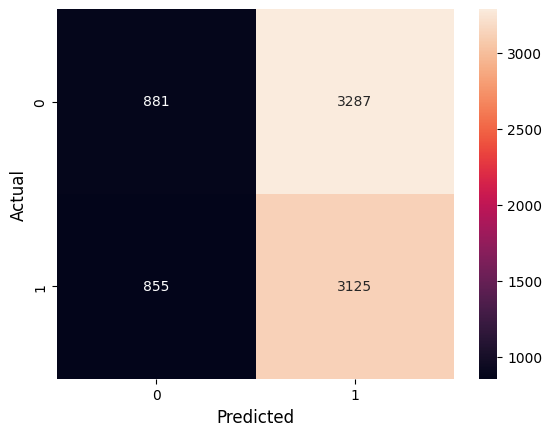

In [ ]:
# Visualize the prediction matrix for RF
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_val, y_val_pred)

sns.heatmap(cm, annot=True, fmt='g')
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.show()

In [ ]:
### XGBOOST TEST ###
from xgboost import XGBClassifier
from sklearn.metrics import f1_score, precision_score, recall_score

### TESTING THE MODEL ###
# Define the Logistic Regression model
xgb = XGBClassifier(random_state=1234)

# Fit the model on the training data
xgb.fit(X_train, y_train)

# Make predictions on the validation set
y_val_pred = xgb.predict(X_val)
y_val_pred_proba = xgb.predict_proba(X_val)[:, 1]

# Calculate the F1 score
f1 = f1_score(y_val, y_val_pred)
precision = precision_score(y_val, y_val_pred)
recall = recall_score(y_val, y_val_pred)
print(f"F1 Score: {f1:.4f}")
print(f"Precision Score: {precision:.4f}")
print(f"Recall Score: {recall:.4f}")

F1 Score: 0.5950
Precision Score: 0.4873
Recall Score: 0.7641


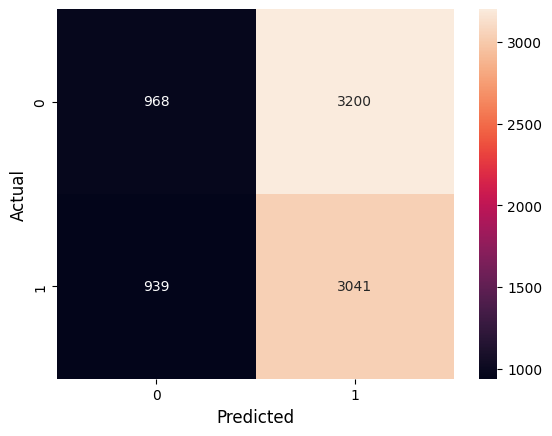

In [ ]:
# Visualize the prediction matrix for XGBoost
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_val, y_val_pred)

sns.heatmap(cm, annot=True, fmt='g')
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.show()

Looking at the performance of the four models measured by F1-scores:
- Logistic Regression: 0.4820
- Decision Tree: 0.5591
- Random Forest: 0.6014
- XGBoost: 0.5950

Based off these results, it is tempting to use Random Forest, but looking at the time it took to achieve these results, XGBoost did so in just a fraction of a second, while Random Forest took several seconds. For performance reasons I am going to move forward, once again, with XGBoost as my primary model.

In [ ]:
# Add financial ratio variables

ratio_df = model_df.copy()

ratio_df['PE_ratio'] = ratio_df['CurrentPrice'] / ratio_df['EarningsPerShareDiluted']
ratio_df['profit_margin'] = ratio_df['NetIncomeLoss'] / ratio_df['TopLineRevenue']
ratio_df['ROE'] = ratio_df['NetIncomeLoss'] / ratio_df['StockholdersEquity']


# Replace infinite values with 0
ratio_df.replace([float('inf'), float('-inf')], 0, inplace=True)

### XGBOOST TEST ###

from xgboost import XGBClassifier
from sklearn.metrics import f1_score, precision_score, recall_score

xgb_df = ratio_df.copy()
xgb_df = xgb_df.sort_values(by=['CurrentPeriodDate','ticker'])


### SET UP THE train_val_test SPLIT ###
# Determine the split point
train_size = int(len(xgb_df) * 0.6)

# Split the data
train_df = xgb_df[:train_size]
temp_df = xgb_df[train_size:]

test_size = int(len(temp_df) * 0.5)

val_df = temp_df[:test_size]
test_df = temp_df[test_size:]


### ENCODE THE TICKER NIL ENCODING ###
# Compute the average NetIncomeLoss per ticker in the training set only
ticker_avg = train_df.groupby('ticker')['NetIncomeLoss'].mean()

# Apply encoding to training data
train_df.loc[:, 'ticker_encoded'] = train_df['ticker'].map(ticker_avg)

# Apply encoding to val and test data using only values from the training set
val_df.loc[:, 'ticker_encoded'] = val_df['ticker'].map(ticker_avg)
test_df.loc[:, 'ticker_encoded'] = test_df['ticker'].map(ticker_avg)

# Handle unseen tickers in test data by filling with the global mean NetIncomeLoss
global_avg = train_df['NetIncomeLoss'].mean()
val_df.loc[:, 'ticker_encoded'].fillna(global_avg, inplace=True)
test_df.loc[:, 'ticker_encoded'].fillna(global_avg, inplace=True)


### SET UP THE MODEL FOR TRAINING ###
target = 'BuySell'

# Drop non-numeric cols (Optional: keep 'Office')
X_train = train_df.drop(columns=[target,'ticker','name','Office'])
y_train = train_df[target]
X_val = val_df.drop(columns=[target,'ticker','name','Office'])
y_val = val_df[target]
X_test = test_df.drop(columns=[target,'ticker','name','Office'])
y_test = test_df[target]

# One-hot encode categorical variables if necessary
X_train = pd.get_dummies(X_train)
X_val = pd.get_dummies(X_val)
X_test = pd.get_dummies(X_test)

# Align the columns of validation and test sets with the training set
X_val = X_val.reindex(columns=X_train.columns, fill_value=0)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

### TESTING THE MODEL ###
# Define the Logistic Regression model
xgb = XGBClassifier(random_state=1234)

# Fit the model on the training data
xgb.fit(X_train, y_train)

# Make predictions on the validation set
y_val_pred = xgb.predict(X_val)
y_val_pred_proba = xgb.predict_proba(X_val)[:, 1]

# Calculate the F1 score
f1 = f1_score(y_val, y_val_pred)
precision = precision_score(y_val, y_val_pred)
recall = recall_score(y_val, y_val_pred)
print(f"F1 Score: {f1:.4f}")
print(f"Precision Score: {precision:.4f}")
print(f"Recall Score: {recall:.4f}")


C:\Users\tjbos\AppData\Local\Temp\ipykernel_22300\1921197336.py:41: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df.loc[:, 'ticker_encoded'] = train_df['ticker'].map(ticker_avg)
C:\Users\tjbos\AppData\Local\Temp\ipykernel_22300\1921197336.py:44: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  val_df.loc[:, 'ticker_encoded'] = val_df['ticker'].map(ticker_avg)
C:\Users\tjbos\AppData\Local\Temp\ipykernel_22300\1921197336.py:45: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from

F1 Score: 0.6091
Precision Score: 0.4854
Recall Score: 0.8176


In [ ]:
# Add vs_prior variables

delta_df = ratio_df.copy()
delta_df = delta_df.sort_values(by=['CurrentPeriodDate','ticker'])

delta_df.head(5)

numeric_features = ('TopLineRevenue', 'OperatingIncomeLoss', 'NetIncomeLoss',
       'EarningsPerShareDiluted', 'CashAndCashEquivalentsAtCarryingValue',
       'StockholdersEquity', 'CurrentPrice', 'Volume','PE_ratio','profit_margin', 'ROE')

for feature in numeric_features:
    delta_df[f"{feature}_vs_prior"] = delta_df.groupby('ticker')[f"{feature}"].diff()

### XGBOOST TEST ###

from xgboost import XGBClassifier
from sklearn.metrics import f1_score, precision_score, recall_score

xgb_df = delta_df.copy()
xgb_df = xgb_df.sort_values(by=['CurrentPeriodDate','ticker'])


### SET UP THE train_val_test SPLIT ###
# Determine the split point
train_size = int(len(xgb_df) * 0.6)

# Split the data
train_df = xgb_df[:train_size]
temp_df = xgb_df[train_size:]

test_size = int(len(temp_df) * 0.5)

val_df = temp_df[:test_size]
test_df = temp_df[test_size:]


### ENCODE THE TICKER NIL ENCODING ###
# Compute the average NetIncomeLoss per ticker in the training set only
ticker_avg = train_df.groupby('ticker')['NetIncomeLoss'].mean()

# Apply encoding to training data
train_df.loc[:, 'ticker_encoded'] = train_df['ticker'].map(ticker_avg)

# Apply encoding to val and test data using only values from the training set
val_df.loc[:, 'ticker_encoded'] = val_df['ticker'].map(ticker_avg)
test_df.loc[:, 'ticker_encoded'] = test_df['ticker'].map(ticker_avg)

# Handle unseen tickers in test data by filling with the global mean NetIncomeLoss
global_avg = train_df['NetIncomeLoss'].mean()
val_df.loc[:, 'ticker_encoded'].fillna(global_avg, inplace=True)
test_df.loc[:, 'ticker_encoded'].fillna(global_avg, inplace=True)


### SET UP THE MODEL FOR TRAINING ###
target = 'BuySell'

# Drop non-numeric cols (Optional: keep 'Office')
X_train = train_df.drop(columns=[target,'ticker','name','Office'])
y_train = train_df[target]
X_val = val_df.drop(columns=[target,'ticker','name','Office'])
y_val = val_df[target]
X_test = test_df.drop(columns=[target,'ticker','name','Office'])
y_test = test_df[target]

# One-hot encode categorical variables if necessary
X_train = pd.get_dummies(X_train)
X_val = pd.get_dummies(X_val)
X_test = pd.get_dummies(X_test)

# Align the columns of validation and test sets with the training set
X_val = X_val.reindex(columns=X_train.columns, fill_value=0)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

### TESTING THE MODEL ###
# Define the Logistic Regression model
xgb = XGBClassifier(random_state=1234)

# Fit the model on the training data
xgb.fit(X_train, y_train)

# Make predictions on the validation set
y_val_pred = xgb.predict(X_val)
y_val_pred_proba = xgb.predict_proba(X_val)[:, 1]

# Calculate the F1 score
f1 = f1_score(y_val, y_val_pred)
precision = precision_score(y_val, y_val_pred)
recall = recall_score(y_val, y_val_pred)
print(f"F1 Score: {f1:.4f}")
print(f"Precision Score: {precision:.4f}")
print(f"Recall Score: {recall:.4f}")


C:\Users\tjbos\AppData\Local\Temp\ipykernel_22300\1802846889.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df.loc[:, 'ticker_encoded'] = train_df['ticker'].map(ticker_avg)
C:\Users\tjbos\AppData\Local\Temp\ipykernel_22300\1802846889.py:46: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  val_df.loc[:, 'ticker_encoded'] = val_df['ticker'].map(ticker_avg)
C:\Users\tjbos\AppData\Local\Temp\ipykernel_22300\1802846889.py:47: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from

F1 Score: 0.6133
Precision Score: 0.5006
Recall Score: 0.7915


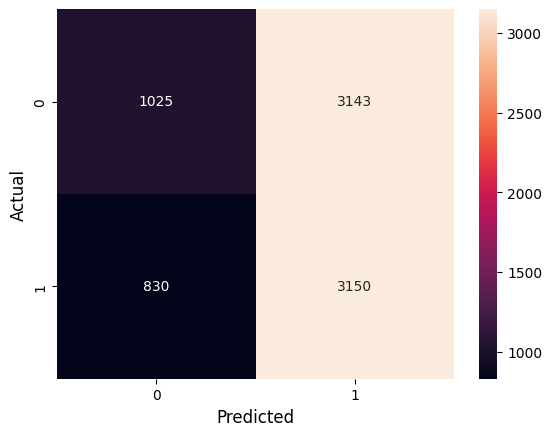

In [ ]:
# Visualize the prediction matrix for XGBoost
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_val, y_val_pred)

sns.heatmap(cm, annot=True, fmt='g')
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.show()

By engineering the ratio features, and their comparison to prior, the performance was "boosted" slightly to an F1 score of 0.6133 which is sufficiently above the goal of 0.5, but looking at the confusion matrix it is clear that this model still makes a lot of mistakes, evidenced by a precision score of just barely above 0.5.

This led me to try my final approach, which involved admitting something crucial about this time series data. When it comes to stock data, one only needs to be able to predict the next period or two, not 5 or 10 periods into the future. This resulted in my final approach which was moving through time, iteratively making predictions and then updating the model as new information became available. This proved to be my most successful model yet:

In [ ]:
from sklearn.metrics import confusion_matrix, roc_auc_score
import pandas as pd
from xgboost import XGBClassifier
from sklearn.preprocessing import label_binarize
import numpy as np

# Assume data is already sorted by ['CurrentPeriodDate', 'ticker']
dates = xgb_df['CurrentPeriodDate'].unique()
results = []

# Initialize counters
tp_total = 0
fp_total = 0
tn_total = 0
fn_total = 0

# For ROC AUC accumulation
y_true_all = []
y_prob_all = []

# For loop iterates through each date in the "test" set
# Calculates the confusion matrix for each date and accumulates totals
for i in range(int(len(dates)*0.6), len(dates) - 1):  # 60% train, 40% test
    train_dates = dates[:i]
    test_date = dates[i]

    # Train data: all previous dates
    train_df = xgb_df[xgb_df['CurrentPeriodDate'].isin(train_dates)].copy()
    test_df = xgb_df[xgb_df['CurrentPeriodDate'] == test_date].copy()

    # Ticker encoding from training data
    ticker_avg = train_df.groupby('ticker')['NetIncomeLoss'].mean()
    global_avg = train_df['NetIncomeLoss'].mean()

    for df in [train_df, test_df]:
        df['ticker_encoded'] = df['ticker'].map(ticker_avg)
        df['ticker_encoded'].fillna(global_avg, inplace=True)

    # Features + target
    target = 'BuySell'
    drop_cols = ['ticker', 'name', 'Office', target]
    X_train = pd.get_dummies(train_df.drop(columns=drop_cols))
    y_train = train_df[target]
    X_test = pd.get_dummies(test_df.drop(columns=drop_cols))
    y_test = test_df[target]

    # Align columns
    X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

    # Binary classification (e.g., 1 = Buy, 0 = Hold/Sell)
    # You must ensure y is binary — adjust logic as needed for your project
    y_train_bin = (y_train == 1).astype(int)
    y_test_bin = (y_test == 1).astype(int)

    # Train model
    model = XGBClassifier(random_state=1234, use_label_encoder=False, eval_metric='logloss')
    model.fit(X_train, y_train_bin)

    # Predict
    y_pred = model.predict(X_test)
    y_pred_prob = model.predict_proba(X_test)[:, 1]  # Prob of class 1

    # Confusion matrix (binary labels: 0 = not buy, 1 = buy)
    tn, fp, fn, tp = confusion_matrix(y_test_bin, y_pred, labels=[0, 1]).ravel()

    # Accumulate confusion matrix counts
    tp_total += tp
    fp_total += fp
    tn_total += tn
    fn_total += fn

    # Store probabilities and true labels for ROC AUC later
    y_true_all.extend(y_test_bin.tolist())
    y_prob_all.extend(y_pred_prob.tolist())

    results.append({
        'date': test_date,
        'tp': tp,
        'fp': fp,
        'tn': tn,
        'fn': fn,
        'n_samples': len(test_df)
    })

# Final aggregate metrics
precision = tp_total / (tp_total + fp_total) if (tp_total + fp_total) > 0 else 0
recall = tp_total / (tp_total + fn_total) if (tp_total + fn_total) > 0 else 0
f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
roc_auc = roc_auc_score(y_true_all, y_prob_all) if len(set(y_true_all)) > 1 else float('nan')  # Handle edge case

print(f"Aggregate Precision: {precision:.4f}")
print(f"Aggregate Recall:    {recall:.4f}")
print(f"Aggregate F1 Score:  {f1:.4f}")
print(f"Aggregate ROC AUC:   {roc_auc:.4f}")


C:\Users\tjbos\AppData\Local\Temp\ipykernel_22300\238177256.py:37: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['ticker_encoded'].fillna(global_avg, inplace=True)
C:\Users\tjbos\AppData\Local\Temp\ipykernel_22300\238177256.py:37: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

Fo

Aggregate Precision: 0.5728
Aggregate Recall:    0.5905
Aggregate F1 Score:  0.5815
Aggregate ROC AUC:   0.6279


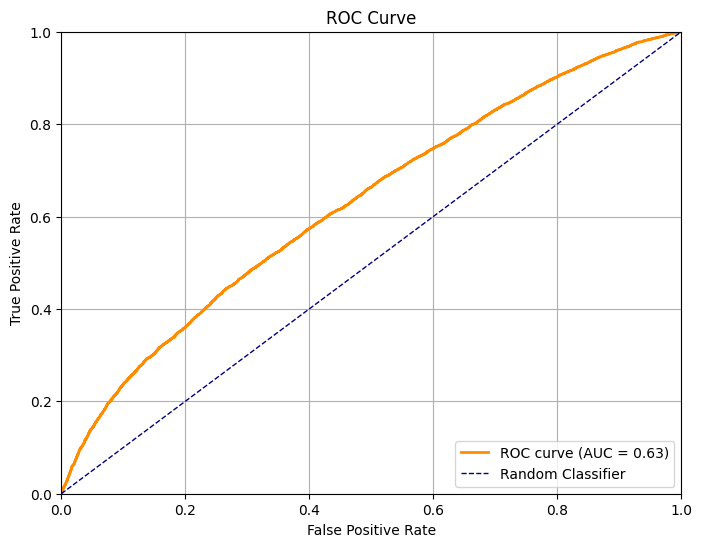

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_true_all, y_prob_all)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.grid()
plt.show()


In [ ]:
print(f"True Positives: {tp_total}")
print(f"False Positives: {fp_total}")
print(f"True Negatives: {tn_total}")
print(f"False Negatives: {fn_total}")

True Positives: 6366
False Positives: 4748
True Negatives: 6584
False Negatives: 4415


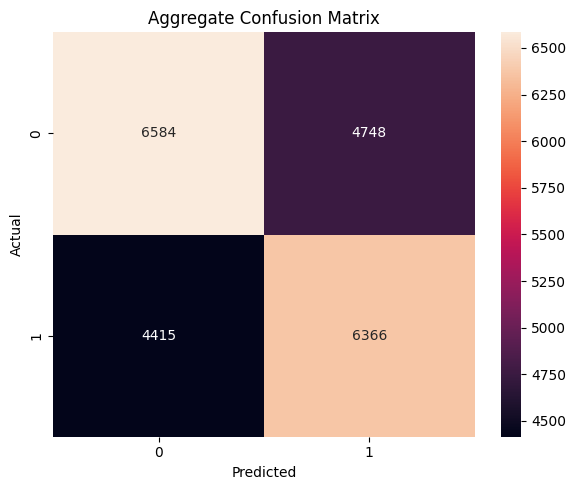

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Confusion matrix in standard format
conf_matrix = np.array([[tn_total, fp_total],
                        [fn_total, tp_total]])

plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d',
            xticklabels=['0', '1'],
            yticklabels=['0', '1'])

plt.title("Aggregate Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


The F1 score of this approach dips slightly compared to before. But what is TRULY important is that our confusion matrix looks much better than before, yielding a recall AND precision well above 0.5. We have traded some of our recall for higher precision.

# Full Analysis

Throughout the course of this project, much was learned about the data and even more insights were gleaned from the modeling phase. During the data joining and cleaning phase, seeing was believing when it came to the messiness and incompleteness of financial data. For the most part it was reasonably structured, but the sheer amount of missing values required some creativity to circumvent. In some cases, features were so sparse that it was not useful at all and needed to be dropped completely. This results in only having a limited number of features to work with, and a notable abscence of some which could be quite useful for predicting our target. One example is Free Cash FLow to price ratio (FCF/Price), which is known to be a good predictor of company health, simply could not be created with the limited data available.

During the EDA phase, the variance in the data was discovered, as well as the near-zero linear correlation of any feature variables with the target. This informed the decision to engineer certain variables. Ratio variables helped normalize the highly varied features, lag variables and "vs prior" variables were designed to show the time dependent nature of the data. From a business knowledge perspective, ratios also make sense as a way to measure a business' performance vs its stock price.

During the initial modeling phase it became clear that the raw data was completely inadequate for predicting the target. Furthermore, even with the engineered variables giving a performance boost, they were still not enough to even get the F1 score over 0.5. The reason F1 score is used as the primary performance metric is because from a stock picking perspective we are interested in performing well on both positive class and negative class since we want to pick from both groups to form our portfolio. For this reason we can leave the default cutoff threshold at 0.5. Furhtermore, the reason for seeking an F1 score >0.5 is that this suggests the model has some predictive power on this balanced data set as opposed to selecting randomly.

Seeing that even with lots of feature engineering, predicting 5 classes correctly was still a struggle for the model, in my model revision phase I decided first to slim down the target from 5 to 2 classes. A simple buy/sell decision on stocks. This is still useful for traders as only the precision of how strongly you should buy or sell it is lost. The base fact of buy/sell still remains and decisions can still be mad with this prediction. After performing this modification to the target variable, the model performance of XGBoost jumped to 0.6 F1 score, a huge improvement and in the realm of usefulness. There was one problem here and that was the precision being almost exactly 0.5. The final idea was realizing that for a predictor to be useful it really only needed to predict one period ahead, and therefore I opted to run the model iteratively through time. It made a prediction, then was fed new data to train on, and would make a prediction again for the next point. This decreased the total F1 score slightly, but it was still a healthy 0.58. The real benefit of this was trading recall for higher precision. Extrapolating this result to portfolio composition, given that the model mades correct predictions greater than 50% of the time, theoretically the expected value of investment return is positive. Of course more testing should be done to ensure this is the case and verify that missed predictions don't drag performance more than the correct ones.

# Final Considerations

This data, feature engineering, and model yielded a meaningful result with decent performance and is satisfactory for further investment performance testing in its current state. However there is still some opportunity to eek out more performance. This modification is conducting transformation of the variables. Currently the ratio variables are acting as a psuedo-transform, but true transformation of variables may have potential as seen in the EDA chart of NetIncomeLoss graphed with a log-transform.